In [1]:
# Setup paths and load libraries
path_to_lucas <- "../../data/reproduce_lucas_wflow"
directory_path <- "../../"

suppressMessages({
    library(SummarizedExperiment)
    library(magrittr)
    library(stringr)
    library(tidyverse)
    library(grid)
    library(lemon)
    library(gridExtra)
    library(cowplot)
    library(data.table)
    library(pROC)
    library(RColorBrewer)
    library(here)
    library(rlucas)
    library(ggsci)
})

source(file.path(path_to_lucas, "code/plot-roc.r"))
data(se, package="rlucas")
rename <- dplyr::rename

dir.create("../../outputs/Extended", recursive = TRUE, showWarnings = FALSE)
dir.create("../../outputs/Fig6", recursive = TRUE, showWarnings = FALSE)

In [2]:
# Load data
metadata <- colData(se) %>% as_tibble()
meta_mica <- read_csv(file.path(directory_path, "data/mica_meta.csv"), show_col_types=FALSE)

load(file.path(directory_path, "models_code/FINAL/train_preds_lucas_c1_FULL.rda"))

# Configuration: Toggle for vertical specificity line in ROC curves
# Set to TRUE to show the grey vertical line at 0.80 specificity, FALSE to hide it
SHOW_SPECIFICITY_LINE <- FALSE

## Prepare Model Data

In [3]:
# Prepare model data subsets
model_levels <- c("DELFI", "Proteomics", "DELFI-Pro Lung")

prepare_model_data <- function(preds, score_col, model_name, metadata) {
    preds %>%
        filter(!is.na(!!sym(score_col))) %>%
        select(id, !!sym(score_col)) %>%
        set_colnames(c("pgdx_id", "score")) %>%
        mutate(training_model = model_name) %>%
        left_join(metadata %>% select(lab_id, pgdx_id), by = "pgdx_id") %>%
        select(-pgdx_id) %>%
        select(lab_id, everything())
}

dat1 <- prepare_model_data(preds, "score.seq", model_levels[1], metadata)
dat2 <- prepare_model_data(preds, "score.olink.only", model_levels[2], metadata)
dat3 <- prepare_model_data(preds, "score.seq.olink", model_levels[3], metadata)

dat <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels))


In [4]:
# Get combined data for plotting
combined <- fig3_data(se, dat1, dat2, dat3)

In [5]:
# Helper function for performance calculation
performance_at_cutoff <- function(x, cutoff) {
    robj <- pROC::roc(class ~ score, x, ret = TRUE, quiet = TRUE)
    tibble(sens = robj$sens, spec = robj$spec, thresholds = robj$thresholds) %>%
        filter(thresholds >= cutoff) %>%
        arrange(thresholds) %>%
        slice(1)
}

## Figure: Model Scores Distribution

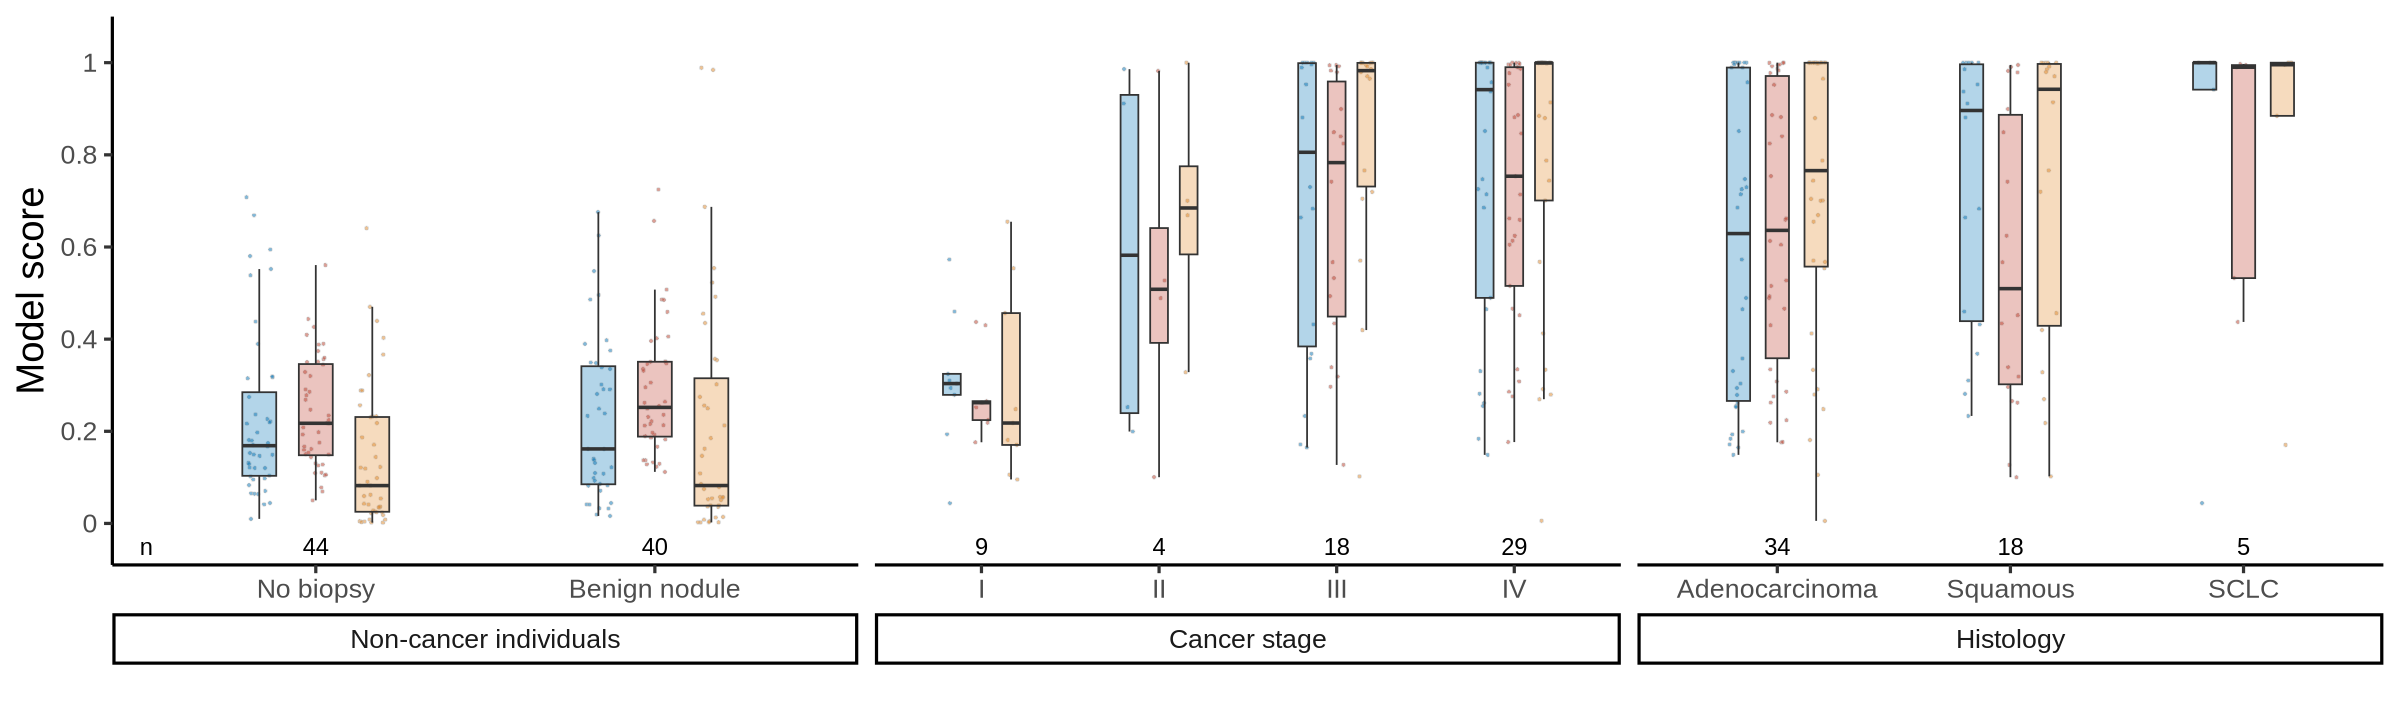

In [6]:
options(repr.plot.width = 20, repr.plot.height = 6)
nejm_colors <- setNames(pal_nejm()(length(model_levels)), model_levels)
nejm_colors[c(1, 2)] <- nejm_colors[c(2, 1)]

combined2 <- combined %>%
    mutate(x = as.character(groups),
           x = ifelse(x == "Non-cancer", "Non-cancer individuals", x),
           groups = factor(x, levels = c("Non-cancer individuals", "Cancer stage", "Histology")))

N <- combined2 %>%
    group_by(category, training_model) %>%
    summarize(n = length(unique(lab_id)),
              groups = unique(groups),
              .groups = "drop") %>%
    mutate(score = -0.05)

middle_model <- model_levels[ceiling(length(model_levels) / 2)]
N_middle <- N %>% filter(training_model == middle_model)

Nlabel <- tibble(groups = levels(N$groups)[1]) %>%
    mutate(groups = factor(groups, levels(N$groups)),
           label = "n", score = -0.05,
           category = levels(N$category)[1],
           category = factor(category, levels(N$category)),
           training_model = N$training_model[1])

A <- combined2 %>%
    ggplot(aes(category, score, fill = training_model)) +
    geom_point(aes(fill = training_model),
               position = position_jitterdodge(0.2, dodge.width = 0.5),
               pch = 21, alpha = 0.5, size = 0.7, color = "gray") +
    geom_boxplot(outlier.shape = NA, alpha = 0.3, width = 0.3,
                 position = position_dodge(0.5)) +
    theme_classic(base_size = 20) +
    theme(panel.grid = element_blank(),
          axis.text.x = element_text(size = 16),
          axis.title.y = element_text(size = 23),
          strip.background = element_rect(fill = "white", color = "black"),
          strip.placement = "outside") +
    scale_y_continuous(expand = expansion(add = c(0.04, 0.1)),
                       breaks = seq(0, 1, by = 0.2),
                       labels = as.character(seq(0, 1, by = 0.2))) +
    xlab("") + ylab("Model score") +
    scale_fill_manual(values = nejm_colors) +
    guides(fill = "none", color = "none") +
    facet_wrap(~groups, nrow = 1, scales = "free_x", strip.position = "bottom") +
    geom_text(data = N_middle, aes(label = n), size = 5, position = position_dodge(0.5)) +
    geom_text(data = Nlabel, aes(x = 0.5, label = "n"), size = 5)
A

In [7]:
ggsave("../../outputs/Fig6/Fig_train_CV_FULL_DELFI_score.png", plot = A, width = 20, height = 6, dpi = 600)

In [7]:
## ── DELFI-Pro scores: Benign nodule vs No biopsy ──
dp_nc <- combined2 %>%
    filter(training_model == "DELFI-Pro Lung",
           category %in% c("No biopsy", "Benign nodule")) %>%
    distinct(lab_id, .keep_all = TRUE)

dp_nc %>%
    group_by(category) %>%
    summarise(n = n(), median = median(score), .groups = "drop") %>%
    print()

wilcox.test(score ~ category, data = dp_nc, exact = FALSE, correct = TRUE)

# A tibble: 2 × 3
  category          n median
  <fct>         <int>  <dbl>
1 No biopsy        44 0.0822
2 Benign nodule    40 0.0823



	Wilcoxon rank sum test with continuity correction

data:  score by category
W = 777, p-value = 0.3586
alternative hypothesis: true location shift is not equal to 0


In [8]:
# Define models and cancer stages
models <- c("DELFI", "Proteomics", "DELFI-Pro Lung")
cancer_stages <- c("I", "II", "III", "IV")

# Perform Wilcoxon tests for each model and stage
wilcox_results <- map_dfr(models, function(model) {
    
    # Filter for current model
    model_data <- combined2 %>%
        filter(training_model == model)
    
    # Get non-cancer scores
    non_cancer_scores <- model_data %>%
        filter(category %in% c("No biopsy", "Benign nodule")) %>%
        pull(score)
    
    # Test each stage vs non-cancer
    map_dfr(cancer_stages, function(stage) {
        stage_scores <- model_data %>%
            filter(category == stage) %>%
            pull(score)
        
        test <- wilcox.test(stage_scores, non_cancer_scores, 
                            exact = FALSE, correct = TRUE)
        
        tibble(
            model = model,
            comparison = paste("Stage", stage, "vs Non-cancer"),
            stage = stage,
            n_stage = length(stage_scores),
            n_non_cancer = length(non_cancer_scores),
            median_stage = median(stage_scores, na.rm = TRUE),
            median_non_cancer = median(non_cancer_scores, na.rm = TRUE),
            W_statistic = test$statistic,
            p_value = test$p.value
        )
    })
})

# Add BH-adjusted p-values within each model
wilcox_results <- wilcox_results %>%
    group_by(model) %>%
    mutate(p_adj_fdr = p.adjust(p_value, method = "BH")) %>%
    ungroup()

# View results
wilcox_results

model,comparison,stage,n_stage,n_non_cancer,median_stage,median_non_cancer,W_statistic,p_value,p_adj_fdr
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DELFI,Stage I vs Non-cancer,I,9,84,0.3035669,0.16449260,509,8.992252e-02,8.992252e-02
DELFI,Stage II vs Non-cancer,II,4,84,0.5820768,0.16449260,272,3.814251e-02,5.085668e-02
DELFI,Stage III vs Non-cancer,III,18,84,0.8055353,0.16449260,1351,1.803512e-07,3.607025e-07
DELFI,Stage IV vs Non-cancer,IV,29,84,0.9414925,0.16449260,2228,3.222963e-11,1.289185e-10
Proteomics,Stage I vs Non-cancer,I,9,84,0.2620752,0.23275866,448,3.664565e-01,3.664565e-01
Proteomics,Stage II vs Non-cancer,II,4,84,0.5082060,0.23275866,248,1.112612e-01,1.483482e-01
Proteomics,Stage III vs Non-cancer,III,18,84,0.7831008,0.23275866,1337,3.475736e-07,6.951473e-07
Proteomics,Stage IV vs Non-cancer,IV,29,84,0.7535845,0.23275866,2232,2.695997e-11,1.078399e-10
DELFI-Pro Lung,Stage I vs Non-cancer,I,9,84,0.2179188,0.08216494,554,2.257406e-02,2.257406e-02


In [10]:
write_csv(wilcox_results, "../../data/DELFI-Pro_stage_wilcox_results.csv")

## Figure: Overall ROC Curves

               comparison  p_raw p_bonferroni  p_fdr
1      DELFI-Pro vs DELFI 0.0990       0.1980 0.0990
2 DELFI-Pro vs Proteomics 0.0403       0.0806 0.0806


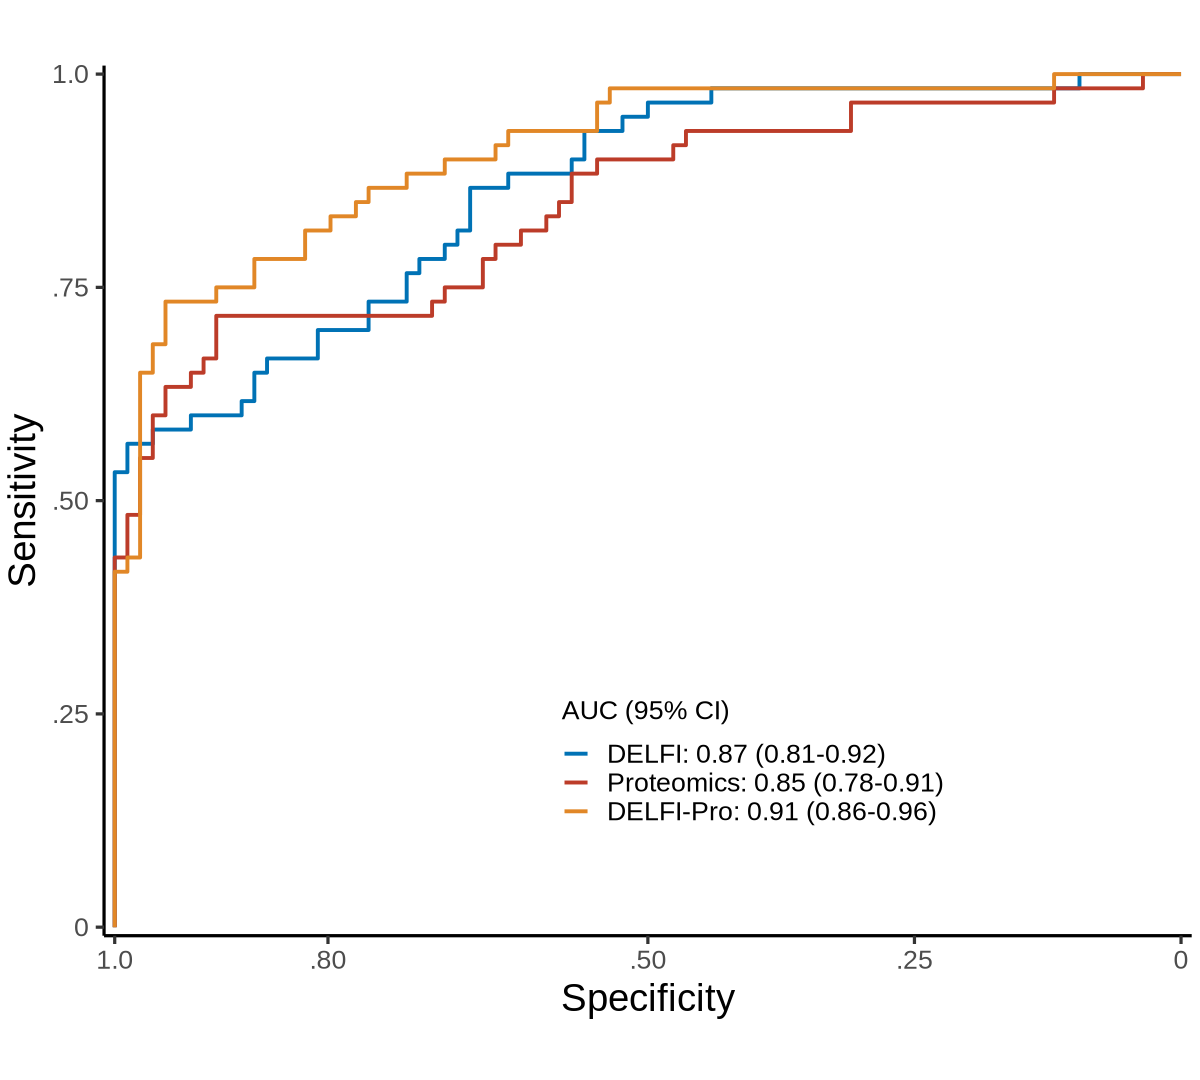

In [9]:
options(repr.plot.width = 10, repr.plot.height = 9, message = FALSE, warning = FALSE)
suppressMessages(suppressWarnings({
    category_levels <- c("No biopsy", "Benign nodule", "I", "II", "III", "IV",
                         "Adenocarcinoma", "Squamous", "SCLC", "Lung metastasis")
    nocancer_labels <- c("no baseline cancer", "benign",
                         "no lung cancer, other cancer",
                         "no lung cancer, later lung cancer")
    clindat <- fig3_clindat(se)
    overall <- bind_rows(dat1, dat2, dat3) %>%
        mutate(training_model = factor(training_model, model_levels)) %>%
        left_join(clindat, by = "lab_id") %>%
        mutate(class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
               class = factor(class, c("No cancer", "Cancer")))
    overall.list <- split(overall, overall$training_model)
    roc_overall <- overall.list %>%
        map_dfr(performance) %>%
        mutate(category = "Overall")

    # ── DeLong pairwise tests ────────────────────────────────────────────
    roc_obj_delfi <- pROC::roc(class ~ score, data = overall.list[[1]], quiet = TRUE)
    roc_obj_prot  <- pROC::roc(class ~ score, data = overall.list[[2]], quiet = TRUE)
    roc_obj_dpro  <- pROC::roc(class ~ score, data = overall.list[[3]], quiet = TRUE)

    delong_vs_delfi <- pROC::roc.test(roc_obj_dpro, roc_obj_delfi, method = "delong")
    delong_vs_prot  <- pROC::roc.test(roc_obj_dpro, roc_obj_prot,  method = "delong")

    # ── Bonferroni AND FDR (Benjamini-Hochberg) correction across the two comparisons ─────
    delong_p_raw <- c(
        `DELFI-Pro vs DELFI`      = delong_vs_delfi$p.value,
        `DELFI-Pro vs Proteomics` = delong_vs_prot$p.value
    )
    delong_p_bonf <- p.adjust(delong_p_raw, method = "bonferroni")
    delong_p_fdr  <- p.adjust(delong_p_raw, method = "BH")   # <- NEW: FDR correction

    # ── Print raw and adjusted p-values ──────────────────────────────────
    print(data.frame(
        comparison   = names(delong_p_raw),
        p_raw        = signif(delong_p_raw,  3),
        p_bonferroni = signif(delong_p_bonf, 3),
        p_fdr        = signif(delong_p_fdr,  3),   # <- NEW
        row.names    = NULL
    ))

    # ── Map training_model levels to display names ───────────────────────
    model_name_lookup <- setNames(
        c("DELFI", "Proteomics", "DELFI-Pro"),
        model_levels
    )

    roc_overall2 <- roc_overall %>%
        mutate(training_model = as.character(training_model),
               model_name = model_name_lookup[training_model],
               auc = format(round(auc, 2), nsmall = 2),
               lower = format(round(lower, 2), nsmall = 2),
               upper = format(round(upper, 2), nsmall = 2),
               auc_label = paste0(model_name, ": ", auc, " (", lower, "-", upper, ")"),
               auc_label = factor(auc_label, unique(auc_label)))

    roc_colors <- setNames(pal_nejm()(length(unique(roc_overall2$auc_label))),
                          levels(roc_overall2$auc_label))
    roc_colors[c(1, 2)] <- roc_colors[c(2, 1)]

    # ── ROC plot ─────────────────────────────────────────────────────────
    B <- roc_overall2 %>%
        ggplot(aes(spec, sens, group = auc_label))

    if(SHOW_SPECIFICITY_LINE) {
        B <- B + geom_vline(xintercept = 0.80, color = "gray80", size = 0.5, linetype = "dashed")
    }

    B <- B +
        geom_line(aes(color = auc_label), size = 1.1) +
        scale_x_reverse(expand = c(0, 0.01),
                        breaks = c(0, 0.25, 0.5, 0.80, 1),
                        labels = as.character(c("0", ".25", ".50", ".80", "1.0"))) +
        scale_y_continuous(expand = c(0, 0.01),
                           breaks = c(0, 0.25, 0.5, 0.75, 1),
                           labels = as.character(c("0", ".25", ".50", ".75", "1.0"))) +
        scale_color_manual(values = roc_colors) +
        theme_classic(base_size = 20) +
        theme(panel.grid = element_blank(),
              legend.position = c(0.6, 0.2),
              aspect.ratio = 0.8,
              legend.text.align = 0,
              legend.title = element_text(size = 16),
              axis.title.y = element_text(size = 23),
              axis.title.x = element_text(size = 23),
              plot.margin = margin(5, 5, 2, 5)) +
        xlab("Specificity") + ylab("Sensitivity") +
        guides(color = guide_legend(title = "AUC (95% CI)", hjust = 1))

    # ── Format p-values (NEJM style) ─────────────────────────────────────
    format_p <- function(p) {
        if (p < 0.001) return("p<0.001")
        return(paste0("p=", formatC(p, format = "f", digits = 3)))
    }

    # ── Footnote grob (single line, left-aligned, NEJM style) ────────────
    delong_footnote <- paste0(
        "DeLong test (Bonferroni / FDR-adjusted):  ",
        "DELFI-Pro vs DELFI, ",
        format_p(delong_p_bonf["DELFI-Pro vs DELFI"]), " / ",
        format_p(delong_p_fdr["DELFI-Pro vs DELFI"]),
        ";  DELFI-Pro vs Proteomics, ",
        format_p(delong_p_bonf["DELFI-Pro vs Proteomics"]), " / ",
        format_p(delong_p_fdr["DELFI-Pro vs Proteomics"])
    )

    footnote_grob <- textGrob(
        delong_footnote,
        x = 0.02, y = 0.5,
        hjust = 0, vjust = 0.5,
        gp = gpar(fontsize = 15, fontface = "plain", col = "black",
                  fontfamily = "sans")
    )

    # ── Combine: ROC on top, footnote below ──────────────────────────────
    combined <- plot_grid(
        B,
        #footnote_grob,
        ncol = 1,
        rel_heights = c(1, 0.04)
    )
}))
combined

In [12]:
ggsave("../../outputs/Fig6/Fig_train_CV_ROC.png", plot = combined, width = 10, height = 8, dpi = 600)

In [10]:
CONF     <- 0.95
N_COMP   <- 2                       # comparisons in the Bonferroni family
alpha    <- 1 - CONF

zc_unadj <- qnorm(1 - alpha / 2)              # 1.960 -> nominal 95% CI
zc_adj   <- qnorm(1 - alpha / (2 * N_COMP))   # 2.241 -> Bonferroni 95% CI

## ---- 1. Common-sample paired matrix ------------------------------------
# dat1/dat2/dat3 each drop their own NAs, so the three ROC objects can end up
# on different sample sets. Force a common, consistently ordered set.
paired_df <- overall %>%
    select(lab_id, class, training_model, score) %>%
    filter(!is.na(score)) %>%
    pivot_wider(names_from = training_model, values_from = score) %>%
    tidyr::drop_na(all_of(model_levels)) %>%
    arrange(lab_id)

n_per_model <- overall %>% filter(!is.na(score)) %>% count(training_model)
cat("Samples per model before pairing:\n"); print(n_per_model)
cat(sprintf("\nComplete-case paired set: %d samples (%d no cancer, %d cancer)\n",
            nrow(paired_df),
            sum(paired_df$class == "No cancer"),
            sum(paired_df$class == "Cancer")))
n_dropped <- max(n_per_model$n) - nrow(paired_df)
if (n_dropped > 0)
    cat(sprintf("NOTE: %d sample(s) dropped by complete-case pairing; AUCs here\n",
                n_dropped),
        "      may differ slightly from the Figure 6B legend.\n")
cat("\n")

## ---- 2. ROC objects on the identical sample set -------------------------
mk_roc <- function(col) {
    pROC::roc(paired_df$class, paired_df[[col]],
              levels = c("No cancer", "Cancer"), direction = "<", quiet = TRUE)
}
r_delfi <- mk_roc(model_levels[1])
r_prot  <- mk_roc(model_levels[2])
r_dpro  <- mk_roc(model_levels[3])

cat("Paired check (must both be TRUE): ",
    pROC::are.paired(r_dpro, r_delfi), " / ",
    pROC::are.paired(r_dpro, r_prot), "\n\n", sep = "")

## ---- 3. DeLong delta AUC, SE, variance components, CIs -----------------
delta_delong <- function(r_ref, r_alt, label) {
    a_ref <- as.numeric(pROC::auc(r_ref))
    a_alt <- as.numeric(pROC::auc(r_alt))
    v_ref <- pROC::var(r_ref, method = "delong")     # NB: pROC:: prefix is
    v_alt <- pROC::var(r_alt, method = "delong")     # required - stats::var
    cv    <- pROC::cov(r_ref, r_alt, method = "delong")  # would silently differ

    d  <- a_ref - a_alt
    se <- sqrt(v_ref + v_alt - 2 * cv)
    z  <- d / se

    tibble(
        comparison = label,
        auc_ref = a_ref, auc_alt = a_alt, delta = d,
        var_ref = v_ref, var_alt = v_alt, cov_refalt = cv,
        cor_auc = cv / sqrt(v_ref * v_alt),
        se = se, z = z,
        p_unadj  = 2 * pnorm(-abs(z)),
        lower_unadj = d - zc_unadj * se, upper_unadj = d + zc_unadj * se,
        lower_adj   = d - zc_adj   * se, upper_adj   = d + zc_adj   * se
    )
}

res_delong <- bind_rows(
    delta_delong(r_dpro, r_delfi, "DELFI-Pro vs DELFI"),
    delta_delong(r_dpro, r_prot,  "DELFI-Pro vs Proteomics")
)

## ---- 4. Stratified paired bootstrap CIs (check on DeLong) --------------
set.seed(2024)
B <- 2000

idx_ctrl <- which(paired_df$class == "No cancer")
idx_case <- which(paired_df$class == "Cancer")

boot_delta <- replicate(B, {
    ii <- c(sample(idx_ctrl, length(idx_ctrl), replace = TRUE),
            sample(idx_case, length(idx_case), replace = TRUE))
    bs <- paired_df[ii, ]
    a <- function(col) as.numeric(pROC::auc(
        pROC::roc(bs$class, bs[[col]], levels = c("No cancer", "Cancer"),
                  direction = "<", quiet = TRUE)))
    a_dpro <- a(model_levels[3])
    c(vs_delfi = a_dpro - a(model_levels[1]),
      vs_prot  = a_dpro - a(model_levels[2]))
})

boot_q <- function(v) {
    c(lo_unadj = unname(quantile(v, alpha / 2)),
      hi_unadj = unname(quantile(v, 1 - alpha / 2)),
      lo_adj   = unname(quantile(v, alpha / (2 * N_COMP))),
      hi_adj   = unname(quantile(v, 1 - alpha / (2 * N_COMP))))
}

res_boot <- bind_rows(
    c(comparison = "DELFI-Pro vs DELFI",      boot_q(boot_delta["vs_delfi", ])),
    c(comparison = "DELFI-Pro vs Proteomics", boot_q(boot_delta["vs_prot",  ]))
) %>%
    mutate(across(-comparison, as.numeric)) %>%
    rename(boot_lower_unadj = lo_unadj, boot_upper_unadj = hi_unadj,
           boot_lower_adj   = lo_adj,   boot_upper_adj   = hi_adj)

## ---- 5. Combine + multiplicity adjustment ------------------------------
delta_auc_table <- res_delong %>%
    left_join(res_boot, by = "comparison") %>%
    mutate(
        p_bonferroni = p.adjust(p_unadj, method = "bonferroni"),
        p_fdr        = p.adjust(p_unadj, method = "BH"),
        ci_unadj      = sprintf("%.3f (%.3f to %.3f)", delta, lower_unadj, upper_unadj),
        ci_adj        = sprintf("%.3f (%.3f to %.3f)", delta, lower_adj,   upper_adj),
        ci_boot_unadj = sprintf("%.3f (%.3f to %.3f)", delta, boot_lower_unadj, boot_upper_unadj),
        ci_boot_adj   = sprintf("%.3f (%.3f to %.3f)", delta, boot_lower_adj,   boot_upper_adj)
    )

cat("---- AUCs and DeLong variance components ----\n")
print(as.data.frame(
    delta_auc_table %>%
        select(comparison, auc_ref, auc_alt, delta,
               var_ref, var_alt, cov_refalt, cor_auc, se)
), row.names = FALSE, digits = 4)

cat("\n---- Delta AUC with 95% CIs and p-values ----\n")
print(as.data.frame(
    delta_auc_table %>%
        select(comparison,
               ci_unadj, p_unadj,
               ci_adj,   p_bonferroni, p_fdr,
               ci_boot_unadj, ci_boot_adj)
), row.names = FALSE, digits = 4)



write_csv(delta_auc_table, "../../outputs/Extended/delta_AUC_delong.csv")

Samples per model before pairing:
# A tibble: 3 × 2
  training_model     n
  <fct>          <int>
1 DELFI            144
2 Proteomics       144
3 DELFI-Pro Lung   144

Complete-case paired set: 144 samples (84 no cancer, 60 cancer)

Paired check (must both be TRUE): TRUE / TRUE

---- AUCs and DeLong variance components ----
              comparison auc_ref auc_alt   delta   var_ref   var_alt cov_refalt
      DELFI-Pro vs DELFI  0.9087  0.8651 0.04365 0.0006225 0.0009077  0.0004151
 DELFI-Pro vs Proteomics  0.9087  0.8462 0.06250 0.0006225 0.0011927  0.0004431
 cor_auc      se
  0.5522 0.02646
  0.5142 0.03048

---- Delta AUC with 95% CIs and p-values ----
              comparison                ci_unadj p_unadj
      DELFI-Pro vs DELFI 0.044 (-0.008 to 0.096) 0.09900
 DELFI-Pro vs Proteomics  0.062 (0.003 to 0.122) 0.04031
                  ci_adj p_bonferroni   p_fdr           ci_boot_unadj
 0.044 (-0.016 to 0.103)      0.19799 0.09900 0.044 (-0.005 to 0.100)
 0.062 (-0.006 to 0.131) 

## Figure: Validation

In [11]:
load(file.path(directory_path, "models_code/FINAL/calibration_set_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_val_mica_c1_FULL.rda"))
load(file.path(directory_path, "models_code/FINAL/test_preds_lucas_c1_FULL.rda"))


In [12]:
# Uses quantile mapping to correct for technical batch shift between LUCAS 
# and MICA. The mapping is learned from non-cancer samples only:
#   - Reference distribution: LUCAS training CV predictions (preds, via dat1/dat2/dat3)
#   - Source distribution:    MICA calibration set (preds_mica_cal) — all healthy
# 
# After calibration, MICA validation scores are on the LUCAS scale, so a 
# single LUCAS-derived threshold can be applied uniformly.

# LUCAS training non-cancer scores (reference distribution)
lucas_train_nocancer <- bind_rows(dat1, dat2, dat3) %>%
    left_join(clindat, by = "lab_id") %>%
    filter(patient_type %in% nocancer_labels)

lucas_nocancer_seq       <- lucas_train_nocancer %>% filter(training_model == model_levels[1]) %>% pull(score)
lucas_nocancer_olink     <- lucas_train_nocancer %>% filter(training_model == model_levels[2]) %>% pull(score)
lucas_nocancer_seq_olink <- lucas_train_nocancer %>% filter(training_model == model_levels[3]) %>% pull(score)

# MICA calibration non-cancer scores (source distribution)
# Calibration set is entirely healthy individuals — no filter needed
mica_cal_nocancer <- preds_mica_cal

# Quantile mapper factory
build_quantile_mapper <- function(source_scores, reference_scores, n_quantiles = 500) {
    probs <- seq(0, 1, length.out = n_quantiles)
    source_q <- quantile(source_scores, probs = probs, na.rm = TRUE)
    ref_q    <- quantile(reference_scores, probs = probs, na.rm = TRUE)
    function(new_scores) {
        approx(x = source_q, y = ref_q, xout = new_scores, rule = 2)$y
    }
}

# Per-model mappers: MICA calibration non-cancer → LUCAS training non-cancer
mapper_seq <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.test,
    reference_scores = lucas_nocancer_seq
)
mapper_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.olink.only.test,
    reference_scores = lucas_nocancer_olink
)
mapper_seq_olink <- build_quantile_mapper(
    source_scores    = mica_cal_nocancer$score.seq.olink.test,
    reference_scores = lucas_nocancer_seq_olink
)

cat("Quantile mappers built from:\n")
cat("  LUCAS training non-cancer:", length(lucas_nocancer_seq), "samples\n")
cat("  MICA calibration non-cancer:", nrow(mica_cal_nocancer), "samples\n\n")

# ---- 2. Prepare LUCAS test set -----------------------------------------

lucas_val <- preds_test %>%
    left_join(metadata %>% select(lab_id, pgdx_id), by = c("id" = "pgdx_id")) %>%
    left_join(clindat %>% select(lab_id, patient_type, stage), by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "LUCAS",
        score.seq       = score.seq.test,
        score.olink     = score.olink.only.test,
        score.seq.olink = score.seq.olink.test
    ) %>%
    select(id, lab_id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

# ---- 3. Prepare calibrated MICA validation set -------------------------

mica_val <- preds_mica_validation %>%
    select(-any_of(c("type", "Stage", "stage"))) %>%
    left_join(
        meta_mica %>% select(id, type, Stage) %>%
            mutate(type = as.character(type), Stage = as.character(Stage)),
        by = "id"
    ) %>%
    mutate(
        class = ifelse(type == "healthy", "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage = Stage,
        stage_combined = case_when(
            Stage %in% c("I", "II")   ~ "I/II",
            Stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        ),
        cohort = "MICA",
        # Apply quantile calibration to map MICA scores → LUCAS scale
        score.seq       = mapper_seq(score.seq.test),
        score.olink     = mapper_olink(score.olink.only.test),
        score.seq.olink = mapper_seq_olink(score.seq.olink.test)
    ) %>%
    select(id, cohort, class, stage, stage_combined,
           score.seq, score.olink, score.seq.olink)

# ---- 4. Combine into final validation set ------------------------------

combined_val <- bind_rows(lucas_val, mica_val)

cat("Combined validation set:\n")
cat("  LUCAS:", nrow(lucas_val), "samples\n")
cat("  MICA: ", nrow(mica_val),  "samples\n")
cat("  Total:", nrow(combined_val), "samples\n\n")

cat("Class breakdown:\n")
combined_val %>%
    count(cohort, class) %>%
    pivot_wider(names_from = class, values_from = n) %>%
    print()

cat("\nCancer by stage:\n")
combined_val %>%
    filter(class == "Cancer") %>%
    count(cohort, stage_combined) %>%
    pivot_wider(names_from = stage_combined, values_from = n, values_fill = 0) %>%
    print()

Quantile mappers built from:
  LUCAS training non-cancer: 84 samples
  MICA calibration non-cancer: 40 samples

Combined validation set:
  LUCAS: 65 samples
  MICA:  360 samples
  Total: 425 samples

Class breakdown:
# A tibble: 2 × 3
  cohort `No cancer` Cancer
  <chr>        <int>  <int>
1 LUCAS           40     25
2 MICA           344     16

Cancer by stage:
# A tibble: 2 × 3
  cohort `I/II` `III/IV`
  <chr>   <int>    <int>
1 LUCAS       5       20
2 MICA        3       13


Datasets to evaluate:
  Training (LUCAS): used for threshold derivation + shown in plot
  Test (LUCAS): 65 samples (40 no cancer, 25 cancer)
  Validation (MICA): 360 samples (344 no cancer, 16 cancer)



Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct =
  FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct =
  FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct =
  FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `ci = list(prop.test(tp, n, conf.level = conf_level, correct =
  FALSE))`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect”
Warning message:
“There was 1 warning in `mutate()`.

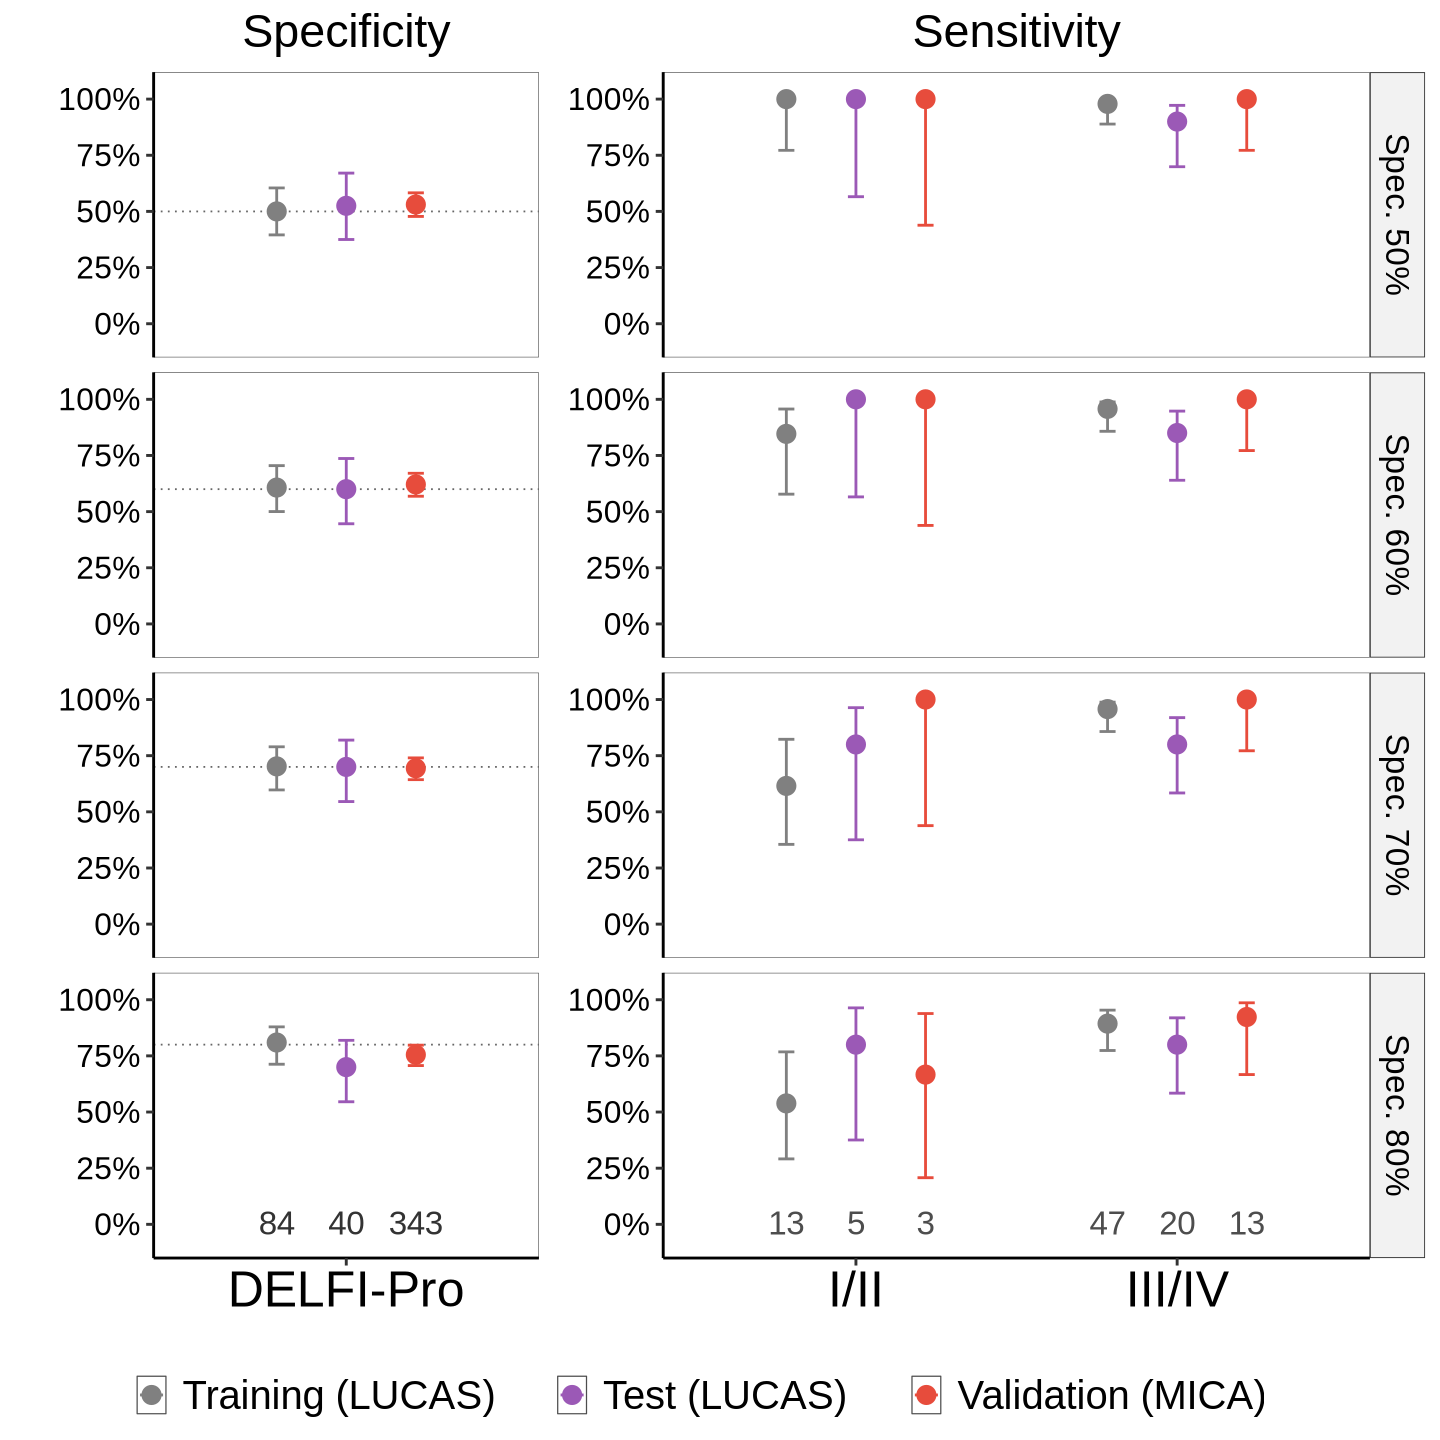

In [13]:
# =============================================================================
# Combined validation figure with locked LUCAS training thresholds
# =============================================================================
create_combined_validation_figure <- function(
    combined_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80),
    models_to_plot = c("DELFI", "DELFI-Pro"),
    validation_set = "combined",
    se_level = 0.95,
    plot_width = 12,
    plot_height = 12
) {

    # ── Validate inputs ──────────────────────────────────────────────────
    valid_val_options <- c("combined", "lucas_test", "mica")
    if (!all(validation_set %in% valid_val_options)) {
        stop(paste("Invalid validation_set option(s). Valid options are:",
                   paste(valid_val_options, collapse = ", ")))
    }

    # ── Facet label formatter (single source of truth) ──────────────────
    spec_label <- function(cutoff) paste0("Spec. ", round(cutoff * 100), "%")

    # ── Model configuration ──────────────────────────────────────────────
    model_map <- list(
        "DELFI" = list(
            idx = 1, dat = dat1,
            score_col = "score.seq",
            display_name = "DELFI"
        ),
        "Proteomics" = list(
            idx = 2, dat = dat2,
            score_col = "score.olink",
            display_name = "Proteomics"
        ),
        "DELFI-Pro" = list(
            idx = 3, dat = dat3,
            score_col = "score.seq.olink",
            display_name = "DELFI-Pro"
        )
    )

    valid_models <- names(model_map)
    if (!all(models_to_plot %in% valid_models)) {
        stop(paste("Invalid model name(s). Valid options are:",
                   paste(valid_models, collapse = ", ")))
    }

    n_cutoffs <- length(specificity_cutoffs)
    n_models  <- length(models_to_plot)
    if (is.null(plot_height)) {
        plot_height <- max(8, n_cutoffs * 3 + 1)
    }

    alpha          <- 1 - se_level
    lower_quantile <- alpha / 2
    upper_quantile <- 1 - alpha / 2

    # ── Helper: clean a validation subset ───────────────────────────────
    clean_val <- function(df) {
        df %>%
            mutate(
                stage_combined = case_when(
                    class == "No cancer"              ~ NA_character_,
                    stage_combined %in% "I/II"        ~ "I/II",
                    stage_combined %in% "III/IV"      ~ "III/IV",
                    TRUE                              ~ NA_character_
                )
            )
    }

    # ── Build validation set list ────────────────────────────────────────
    val_sets <- list()
    if ("combined" %in% validation_set) {
        val_sets[["Combined (LUCAS test + MICA)"]] <- clean_val(combined_val)
    }
    if ("lucas_test" %in% validation_set) {
        val_sets[["Test (LUCAS)"]] <- combined_val %>%
            filter(cohort == "LUCAS") %>%
            clean_val()
    }
    if ("mica" %in% validation_set) {
        val_sets[["Validation (MICA)"]] <- combined_val %>%
            filter(cohort == "MICA") %>%
            clean_val()
    }

    cat("Datasets to evaluate:\n")
    cat("  Training (LUCAS): used for threshold derivation + shown in plot\n")
    for (nm in names(val_sets)) {
        d <- val_sets[[nm]]
        cat(sprintf("  %s: %d samples (%d no cancer, %d cancer)\n",
                    nm, nrow(d),
                    sum(d$class == "No cancer"), sum(d$class == "Cancer")))
    }
    cat("\n")

    # ── LUCAS training data (for threshold derivation ONLY) ──────────────
    overall <- bind_rows(dat1, dat2, dat3) %>%
        mutate(training_model = factor(training_model, model_levels)) %>%
        left_join(clindat, by = "lab_id") %>%
        mutate(
            class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
            class = factor(class, c("No cancer", "Cancer")),
            stage_combined = case_when(
                stage %in% c("I", "II")   ~ "I/II",
                stage %in% c("III", "IV") ~ "III/IV",
                TRUE                      ~ NA_character_
            )
        )
    overall.list <- split(overall, overall$training_model)

    # ── Helper: evaluate a dataset at a locked threshold ─────────────────
    evaluate_at_threshold <- function(data, score_col, threshold,
                                      lower_q, upper_q) {

        conf_level <- 2 * upper_q - 1

        scores <- data %>%
            select(class, stage = stage_combined, score = !!sym(score_col)) %>%
            filter(!is.na(score))

        # Specificity
        nocancer <- scores %>% filter(class == "No cancer")
        n_nc     <- nrow(nocancer)
        tn       <- sum(nocancer$score < threshold)
        spec_ci  <- prop.test(tn, n_nc, conf.level = conf_level, correct = FALSE)

        # Sensitivity by stage
        stage_perf <- scores %>%
            filter(class == "Cancer", !is.na(stage)) %>%
            group_by(stage) %>%
            summarise(n = n(), tp = sum(score >= threshold), .groups = "drop") %>%
            rowwise() %>%
            mutate(
                ci    = list(prop.test(tp, n, conf.level = conf_level, correct = FALSE)),
                sens  = ci$estimate,
                lower = ci$conf.int[1],
                upper = ci$conf.int[2]
            ) %>%
            select(-ci) %>%
            ungroup()

        bind_rows(
            tibble(
                stage = "0", value = unname(spec_ci$estimate), n = n_nc,
                lower = spec_ci$conf.int[1], upper = spec_ci$conf.int[2],
                statistic = "Specificity"
            ),
            stage_perf %>% transmute(
                stage, value = sens, n,
                lower, upper,
                statistic = "Sensitivity"
            )
        )
    }

    # ── Main loop ────────────────────────────────────────────────────────
    all_perf <- list()

    for (spec_cutoff in specificity_cutoffs) {
        for (model_name in models_to_plot) {
            model_info <- model_map[[model_name]]

            # ── Lock threshold from LUCAS TRAINING ROC ───────────────────
            lucas_roc_data <- overall.list[[model_info$idx]] %>%
                select(score, class)
            tmp <- pROC::roc(class ~ score, data = lucas_roc_data,
                             ret = TRUE, quiet = TRUE)
            cutoff_row <- tibble(
                sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
            ) %>%
                filter(spec >= spec_cutoff) %>%
                arrange(spec) %>%
                slice(1)
            locked_threshold <- cutoff_row$thresholds

            # ── Evaluate on LUCAS training set ───────────────────────────
            train_data <- overall.list[[model_info$idx]]
            train_perf <- evaluate_at_threshold(
                train_data, "score", locked_threshold,
                lower_quantile, upper_quantile
            ) %>% mutate(dataset = "Training (LUCAS)")

            all_perf[[paste(spec_cutoff, model_name, "train", sep = "_")]] <- train_perf %>%
                mutate(
                    model              = model_info$display_name,
                    specificity_cutoff = spec_cutoff,
                    specificity_label  = spec_label(spec_cutoff),
                    locked_threshold   = locked_threshold
                )

            # ── Evaluate on each selected validation set ─────────────────
            for (val_name in names(val_sets)) {
                val_perf <- evaluate_at_threshold(
                    val_sets[[val_name]], model_info$score_col, locked_threshold,
                    lower_quantile, upper_quantile
                ) %>% mutate(dataset = val_name)

                all_perf[[paste(spec_cutoff, model_name, val_name, sep = "_")]] <- val_perf %>%
                    mutate(
                        model              = model_info$display_name,
                        specificity_cutoff = spec_cutoff,
                        specificity_label  = spec_label(spec_cutoff),
                        locked_threshold   = locked_threshold
                    )
            }
        }
    }

    # ── Combine all results ──────────────────────────────────────────────
    model_display_levels <- sapply(models_to_plot, function(m) model_map[[m]]$display_name)
    dataset_levels <- c("Training (LUCAS)", names(val_sets))

    combined_perf <- bind_rows(all_perf) %>%
        mutate(
            dataset = factor(dataset, levels = dataset_levels),
            stage = factor(stage, c("0", "I/II", "III/IV")),
            statistic = factor(statistic, c("Specificity", "Sensitivity")),
            specificity_label = factor(
                specificity_label,
                levels = spec_label(sort(specificity_cutoffs))
            ),
            model  = factor(model, levels = model_display_levels),
            stage0 = as.character(stage),
            stage0 = ifelse(stage0 == "0", "Non-Cancer", stage0),
            stage0 = factor(stage0, c("Non-Cancer", "I/II", "III/IV"))
        )

    # ── X-axis labels ────────────────────────────────────────────────────
    if (n_models == 1) {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ as.character(stage0)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ 1,
                    TRUE ~ as.numeric(stage0)
                )
            )
    } else {
        combined_perf <- combined_perf %>%
            mutate(
                x_label = case_when(
                    statistic == "Specificity" ~ as.character(model),
                    TRUE ~ paste0(stage0, "\n", model)
                ),
                x_order = case_when(
                    statistic == "Specificity" ~ as.numeric(model),
                    TRUE ~ as.numeric(stage0) * 100 + as.numeric(model)
                )
            )
    }

    spec_levels <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    sens_levels <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        distinct(x_label, x_order) %>% arrange(x_order) %>% pull(x_label)

    spec_perf <- combined_perf %>%
        filter(statistic == "Specificity") %>%
        mutate(x_label = factor(x_label, levels = spec_levels))

    sens_perf <- combined_perf %>%
        filter(statistic == "Sensitivity") %>%
        mutate(x_label = factor(x_label, levels = sens_levels))

    # ── N labels: only for the highest specificity facet ────────────────
    highest_spec_label <- spec_label(max(specificity_cutoffs))

    spec_N <- spec_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    sens_N <- sens_perf %>%
        filter(specificity_label == highest_spec_label) %>%
        select(x_label, n, dataset, specificity_label)

    # ── Reference lines ──────────────────────────────────────────────────
    hline_data <- tibble(
        specificity_label = factor(
            spec_label(specificity_cutoffs),
            levels = spec_label(sort(specificity_cutoffs))
        ),
        yintercept = specificity_cutoffs
    )

    # ── Colors ───────────────────────────────────────────────────────────
    all_possible_colors2 <- c(
        "Training (LUCAS)"             = "#808080",
        "Test (LUCAS)"                 = "#9b59b6",
        "Validation (MICA)"            = "#e74c3c",
        "Combined (LUCAS test + MICA)" = "#2ecc71"
    )
    dataset_colors <- all_possible_colors2[dataset_levels]

    # ── Plotting ─────────────────────────────────────────────────────────
    options(repr.plot.width = plot_width, repr.plot.height = plot_height,
            message = FALSE, warning = FALSE)

    n_datasets  <- length(dataset_levels)
    dodge_width <- position_dodge(width = 0.15 * n_datasets + 0.2)

    shared_theme <- theme_classic(base_size = 18) +
        theme(
            panel.grid         = element_blank(),
            panel.background   = element_rect(fill = "white", color = "gray30"),
            strip.background   = element_rect(fill = "gray95", color = "gray30",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 19, color = "black"),
            rect               = element_blank(),
            axis.text          = element_text(size = 19, color = "black"),
            axis.title.x       = element_blank(),
            axis.title.y       = element_text(size = 24)
        )

    shared_y_scale <- scale_y_continuous(
        breaks = seq(0, 1, 0.25),
        labels = scales::percent_format(accuracy = 1),
        limits = c(-0.15, 1.10),
        expand = expansion(add = c(0, 0.02))
    )

    # ── Left panel: Specificity ──────────────────────────────────────────
    p_spec <- ggplot(spec_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_hline(data = hline_data,
                   aes(yintercept = yintercept),
                   linetype = "dotted", color = "gray40", linewidth = 0.5) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = spec_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray20", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "none",
            strip.text.y.right = element_blank(),
            strip.background   = element_blank(),
            axis.text.x        = element_text(size = 30)
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        ylab(" ") +
        ggtitle("Specificity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Right panel: Sensitivity ─────────────────────────────────────────
    p_sens <- ggplot(sens_perf,
                     aes(x = x_label, y = value, group = dataset)) +
        geom_errorbar(aes(ymin = lower, ymax = upper, color = dataset),
                      width = 0.15, linewidth = 0.8, position = dodge_width) +
        geom_point(aes(color = dataset), size = 5, position = dodge_width) +
        geom_text(data = sens_N,
                  aes(x = x_label, y = -0.10, label = paste0(n, "\n")),
                  position = dodge_width, color = "gray30", size = 7) +
        facet_grid(specificity_label ~ .) +
        shared_theme +
        theme(
            legend.position    = "bottom",
            legend.direction   = "horizontal",
            legend.text        = element_text(size = 22),
            strip.background   = element_rect(fill = "gray95", color = "gray20",
                                              linewidth = 0.5),
            strip.text.y.right = element_text(angle = 270, size = 20, color = "black"),
            strip.placement    = "outside",
            axis.text.x        = element_text(size = 30),
            axis.title.y       = element_blank()
        ) +
        scale_color_manual(values = dataset_colors) +
        shared_y_scale +
        guides(color = guide_legend(title = "", ncol = 1)) +
        ggtitle("Sensitivity") +
        theme(plot.title = element_text(hjust = 0.5, size = 28))

    # ── Combine panels ───────────────────────────────────────────────────
    right_width <- 1 + n_models * 0.6

    legend <- get_legend(
        p_sens +
            theme(
                legend.position   = "bottom",
                legend.direction  = "horizontal",
                legend.text       = element_text(size = 24,
                                                 margin = margin(l = 10, r = 30, unit = "pt")),
                legend.box.margin = margin(t = 10),
                legend.spacing.x  = unit(2.0, "cm")
            ) +
            guides(color = guide_legend(
                title = "", nrow = 1,
                override.aes = list(size = 5),
                byrow = TRUE
            ))
    )

    p_spec <- p_spec + theme(legend.position = "none")
    p_sens <- p_sens + theme(legend.position = "none")

    plot_row <- plot_grid(
        p_spec, p_sens,
        nrow = 1,
        rel_widths = c(1, right_width),
        align = "h",
        axis  = "tb"
    )

    combined_plot <- plot_grid(
        plot_row, legend,
        ncol = 1,
        rel_heights = c(1, 0.08)
    )

    return(combined_plot)
}

# =====================================================================
# USAGE EXAMPLES
# =====================================================================

p2 <- create_combined_validation_figure(
    combined_val,
    specificity_cutoffs = c(0.50, 0.60, 0.70, 0.80),
    models_to_plot = c("DELFI-Pro"),
    validation_set = c("lucas_test", "mica"),
    se_level = 0.95,
    plot_width = 12
)
p2

In [17]:
ggsave("../../outputs/Fig6/Fig-DELFI-Pro-Locked-Threshold.png",
       plot = p2, width = 12, height = 14, units = "in", dpi = 600)

In [14]:
# Get the locked threshold from LUCAS training at 60% specificity
model_info <- list(
    idx = 3, 
    score_col = "score.seq.olink",
    display_name = "DELFI-Pro"
)

# Build LUCAS training data
overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        )
    )
overall.list <- split(overall, overall$training_model)

# Get threshold at 60% specificity from LUCAS training ROC
lucas_roc_data <- overall.list[[model_info$idx]] %>%
    select(score, class)
tmp <- pROC::roc(class ~ score, data = lucas_roc_data, ret = TRUE, quiet = TRUE)
cutoff_row <- tibble(
    sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
) %>%
    filter(spec >= 0.60) %>%
    arrange(spec) %>%
    slice(1)
locked_threshold <- cutoff_row$thresholds

# Combine LUCAS train and LUCAS test
lucas_train <- overall.list[[model_info$idx]] %>%
    mutate(score_col = score)

lucas_test <- combined_val %>% 
    filter(cohort == "LUCAS") %>%
    mutate(score_col = score.seq.olink)

lucas_combined <- bind_rows(
    lucas_train %>% select(class, stage_combined, score_col),
    lucas_test %>% select(class, stage_combined, score_col)
)

# Calculate sensitivity by stage at the locked threshold
sensitivity_by_stage <- lucas_combined %>%
    filter(class == "Cancer", !is.na(stage_combined)) %>%
    group_by(stage_combined) %>%
    summarise(
        n = n(),
        tp = sum(score_col >= locked_threshold),
        sensitivity = tp / n,
        .groups = "drop"
    )

print(paste("Locked threshold at 60% specificity:", round(locked_threshold, 4)))
print(sensitivity_by_stage)

[1] "Locked threshold at 60% specificity: 0.1455"
# A tibble: 2 × 4
  stage_combined     n    tp sensitivity
  <chr>          <int> <int>       <dbl>
1 I/II              18    16       0.889
2 III/IV            67    62       0.925


In [15]:
# Get the locked threshold from LUCAS training at 60% specificity
model_info <- list(
    idx = 3, 
    score_col = "score.seq.olink",
    display_name = "DELFI-Pro"
)

# Build LUCAS training data
overall <- bind_rows(dat1, dat2, dat3) %>%
    mutate(training_model = factor(training_model, model_levels)) %>%
    left_join(clindat, by = "lab_id") %>%
    mutate(
        class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
        class = factor(class, c("No cancer", "Cancer")),
        stage_combined = case_when(
            stage %in% c("I", "II")   ~ "I/II",
            stage %in% c("III", "IV") ~ "III/IV",
            TRUE                      ~ NA_character_
        )
    )
overall.list <- split(overall, overall$training_model)

# Get threshold at 60% specificity from LUCAS training ROC
lucas_roc_data <- overall.list[[model_info$idx]] %>%
    select(score, class)
tmp <- pROC::roc(class ~ score, data = lucas_roc_data, ret = TRUE, quiet = TRUE)
cutoff_row <- tibble(
    sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
) %>%
    filter(spec >= 0.60) %>%
    arrange(spec) %>%
    slice(1)
locked_threshold <- cutoff_row$thresholds

print(paste("Locked threshold at 60% specificity:", round(locked_threshold, 4)))

# Prepare each dataset
lucas_train <- overall.list[[model_info$idx]] %>%
    mutate(score_col = score, dataset = "LUCAS (train)")

lucas_test <- combined_val %>% 
    filter(cohort == "LUCAS") %>%
    mutate(score_col = score.seq.olink, dataset = "LUCAS (test)")

mica <- combined_val %>% 
    filter(cohort == "MICA") %>%
    mutate(score_col = score.seq.olink, dataset = "MICA (validation)")

# Combine all datasets
all_data <- bind_rows(
    lucas_train %>% select(class, stage_combined, score_col, dataset),
    lucas_test %>% select(class, stage_combined, score_col, dataset),
    mica %>% select(class, stage_combined, score_col, dataset)
)

# Calculate sensitivity by stage and dataset at the locked threshold
sensitivity_by_stage_dataset <- all_data %>%
    filter(class == "Cancer", !is.na(stage_combined)) %>%
    group_by(dataset, stage_combined) %>%
    summarise(
        n = n(),
        tp = sum(score_col >= locked_threshold),
        sensitivity = tp / n,
        sens_pct = paste0(round(sensitivity * 100, 1), "%"),
        .groups = "drop"
    ) %>%
    arrange(dataset, stage_combined)

print(sensitivity_by_stage_dataset)

# Pivot to a wider format for easier viewing
sensitivity_wide <- sensitivity_by_stage_dataset %>%
    select(dataset, stage_combined, sens_pct) %>%
    pivot_wider(names_from = stage_combined, values_from = sens_pct)

print(sensitivity_wide)

[1] "Locked threshold at 60% specificity: 0.1455"
# A tibble: 6 × 6
  dataset           stage_combined     n    tp sensitivity sens_pct
  <chr>             <chr>          <int> <int>       <dbl> <chr>   
1 LUCAS (test)      I/II               5     5       1     100%    
2 LUCAS (test)      III/IV            20    17       0.85  85%     
3 LUCAS (train)     I/II              13    11       0.846 84.6%   
4 LUCAS (train)     III/IV            47    45       0.957 95.7%   
5 MICA (validation) I/II               3     3       1     100%    
6 MICA (validation) III/IV            13    13       1     100%    
# A tibble: 3 × 3
  dataset           `I/II` `III/IV`
  <chr>             <chr>  <chr>   
1 LUCAS (test)      100%   85%     
2 LUCAS (train)     84.6%  95.7%   
3 MICA (validation) 100%   100%    


## Performance across different sets

In [16]:
# =====================================================================
# AUC + DeLong 95% CI, UNCALIBRATED scores
#   - LUCAS held-out test set   (preds_test)
#   - MICA validation set       (preds_mica_validation, raw / no quantile map)
# All three models: DELFI, Proteomics, DELFI-Pro


## ---- 1. LUCAS held-out test set (raw by construction) ------------------
lucas_test_raw <- preds_test %>%
    left_join(metadata %>% select(lab_id, pgdx_id), by = c("id" = "pgdx_id")) %>%
    left_join(clindat %>% select(lab_id, patient_type), by = "lab_id") %>%
    transmute(
        id,
        cohort = "LUCAS test",
        class  = factor(ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
                        levels = c("No cancer", "Cancer")),
        DELFI            = score.seq.test,
        Proteomics       = score.olink.only.test,
        `DELFI-Pro`      = score.seq.olink.test
    )

## ---- 2. MICA validation set, RAW (no quantile calibration) -------------
mica_valid_raw <- preds_mica_validation %>%
    select(-any_of(c("type", "Stage", "stage"))) %>%
    left_join(meta_mica %>% select(id, type) %>% mutate(type = as.character(type)),
              by = "id") %>%
    transmute(
        id,
        cohort = "MICA validation",
        class  = factor(ifelse(type == "healthy", "No cancer", "Cancer"),
                        levels = c("No cancer", "Cancer")),
        DELFI            = score.seq.test,
        Proteomics       = score.olink.only.test,
        `DELFI-Pro`      = score.seq.olink.test
    )

# drop any individual used to fit the calibration mapper (defensive; should be 0)
cal_ids <- if (exists("mica_cal_nocancer")) mica_cal_nocancer$id else preds_mica_cal$id
n_drop  <- sum(mica_valid_raw$id %in% cal_ids)
mica_valid_raw <- mica_valid_raw %>% filter(!id %in% cal_ids)

## ---- 3. AUC + DeLong 95% CI -------------------------------------------
auc_table <- bind_rows(lucas_test_raw, mica_valid_raw) %>%
    pivot_longer(c(DELFI, Proteomics, `DELFI-Pro`),
                 names_to = "model", values_to = "score") %>%
    filter(!is.na(score)) %>%
    group_by(cohort, model) %>%
    group_modify(~ {
        r  <- pROC::roc(class ~ score, data = .x, quiet = TRUE,
                        levels = c("No cancer", "Cancer"), direction = "<")
        ci <- pROC::ci.auc(r, conf.level = 0.95, method = "delong")
        tibble(
            auc   = as.numeric(ci[2]),
            lower = as.numeric(ci[1]),
            upper = as.numeric(ci[3])
        )
    }) %>%
    ungroup() %>%
    mutate(
        model  = factor(model, levels = c("DELFI", "Proteomics", "DELFI-Pro")),
        cohort = factor(cohort, levels = c("LUCAS test", "MICA validation")),
        label  = sprintf("%.2f (%.2f-%.2f)", auc, lower, upper)
    ) %>%
    arrange(cohort, model)
print(as.data.frame(auc_table), row.names = FALSE, digits = 4)

          cohort      model    auc  lower  upper            label
      LUCAS test      DELFI 0.8860 0.8034 0.9686 0.89 (0.80-0.97)
      LUCAS test Proteomics 0.8690 0.7795 0.9585 0.87 (0.78-0.96)
      LUCAS test  DELFI-Pro 0.8820 0.7927 0.9713 0.88 (0.79-0.97)
 MICA validation      DELFI 0.8989 0.8414 0.9563 0.90 (0.84-0.96)
 MICA validation Proteomics 0.8717 0.7814 0.9621 0.87 (0.78-0.96)
 MICA validation  DELFI-Pro 0.9153 0.8594 0.9712 0.92 (0.86-0.97)


In [21]:
## ---- 5. DeLong tests: DELFI-Pro vs DELFI, DELFI-Pro vs Proteomics -----
delong_compare <- function(df, model_a, model_b) {
  roc_a <- pROC::roc(class ~ get(model_a), data = df, quiet = TRUE,
                     levels = c("No cancer", "Cancer"), direction = "<")
  roc_b <- pROC::roc(class ~ get(model_b), data = df, quiet = TRUE,
                     levels = c("No cancer", "Cancer"), direction = "<")
  test  <- pROC::roc.test(roc_a, roc_b, method = "delong")
  tibble(
    model_a = model_a, model_b = model_b,
    auc_a = as.numeric(pROC::auc(roc_a)),
    auc_b = as.numeric(pROC::auc(roc_b)),
    auc_diff = as.numeric(pROC::auc(roc_a)) - as.numeric(pROC::auc(roc_b)),
    statistic = unname(test$statistic),
    p_value   = test$p.value
  )
}

delong_table <- bind_rows(lucas_test_raw, mica_valid_raw) %>%
  group_by(cohort) %>%
  group_modify(~ bind_rows(
    delong_compare(.x, "DELFI-Pro", "DELFI"),
    delong_compare(.x, "DELFI-Pro", "Proteomics")
  )) %>%
  ungroup() %>%
  mutate(
    cohort = factor(cohort, levels = c("LUCAS test", "MICA validation")),
    comparison = paste(model_a, "vs", model_b),
    label = sprintf("ΔAUC = %.3f, P = %s",
                    auc_diff, ifelse(p_value < 0.001, "< 0.001", sprintf("%.3f", p_value)))
  ) %>%
  select(cohort, comparison, auc_a, auc_b, auc_diff, statistic, p_value, label) %>%
  arrange(cohort, comparison)

print(as.data.frame(delong_table), row.names = FALSE, digits = 4)

          cohort              comparison  auc_a  auc_b auc_diff statistic
      LUCAS test      DELFI-Pro vs DELFI 0.8820 0.8860 -0.00400   -0.1609
      LUCAS test DELFI-Pro vs Proteomics 0.8820 0.8690  0.01300    0.3924
 MICA validation      DELFI-Pro vs DELFI 0.9153 0.8989  0.01640    0.7345
 MICA validation DELFI-Pro vs Proteomics 0.9153 0.8717  0.04354    1.5449
 p_value                    label
  0.8722 ΔAUC = -0.004, P = 0.872
  0.6948  ΔAUC = 0.013, P = 0.695
  0.4627  ΔAUC = 0.016, P = 0.463
  0.1224  ΔAUC = 0.044, P = 0.122


In [22]:
compare_sensitivity_at_spec <- function(spec_cutoff, combined_val,
                                        dat1, dat2, dat3, clindat,
                                        model_levels, nocancer_labels,
                                        se_level = 0.95) {

  conf_level <- se_level

  ## ── Rebuild labeled training set (mirrors `overall` in the original fn) ──
  overall <- dplyr::bind_rows(dat1, dat2, dat3) %>%
    dplyr::mutate(training_model = factor(training_model, model_levels)) %>%
    dplyr::left_join(clindat, by = "lab_id") %>%
    dplyr::mutate(
      class = ifelse(patient_type %in% nocancer_labels, "No cancer", "Cancer"),
      class = factor(class, c("No cancer", "Cancer"))
    )
  overall.list <- split(overall, overall$training_model)

  ## ── Lock threshold at spec_cutoff on LUCAS TRAINING, per model ──
  lock_threshold <- function(idx) {
    roc_obj <- pROC::roc(class ~ score,
                         data = overall.list[[idx]] %>% dplyr::select(score, class),
                         quiet = TRUE)
    tibble::tibble(spec = roc_obj$spec, thr = roc_obj$thresholds) %>%
      dplyr::filter(spec >= spec_cutoff) %>%
      dplyr::arrange(spec) %>% dplyr::slice(1) %>% dplyr::pull(thr)
  }
  thr_delfi     <- lock_threshold(1)   # matches model_map$DELFI$idx
  thr_delfipro  <- lock_threshold(3)   # matches model_map$`DELFI-Pro`$idx

  ## ── LUCAS test set, calls from both models ──
  lucas_test <- combined_val %>%
    dplyr::filter(cohort == "LUCAS", class == "Cancer") %>%
    dplyr::mutate(
      call_delfi    = score.seq       >= thr_delfi,
      call_delfipro = score.seq.olink >= thr_delfipro
    )

  ## ── Sensitivity + CI per model ──
  sens_ci <- function(call_col) {
    ci <- prop.test(sum(lucas_test[[call_col]]), nrow(lucas_test),
                    conf.level = conf_level, correct = FALSE)
    tibble::tibble(n = nrow(lucas_test), sensitivity = unname(ci$estimate),
                   lower = ci$conf.int[1], upper = ci$conf.int[2])
  }
  perf_table <- dplyr::bind_rows(
    DELFI     = sens_ci("call_delfi"),
    `DELFI-Pro` = sens_ci("call_delfipro"),
    .id = "model"
  )

  ## ── Paired test: same patients, both models ──
  mcnemar <- mcnemar.test(table(lucas_test$call_delfi, lucas_test$call_delfipro))

  list(spec_cutoff = spec_cutoff, thresholds = c(DELFI = thr_delfi, `DELFI-Pro` = thr_delfipro),
       perf_table = perf_table, mcnemar = mcnemar)
}

res <- compare_sensitivity_at_spec(0.95, combined_val, dat1, dat2, dat3,
                                   clindat, model_levels, nocancer_labels)
res$perf_table
res$mcnemar

model,n,sensitivity,lower,upper
<chr>,<int>,<dbl>,<dbl>,<dbl>
DELFI,25,0.64,0.4451850,0.7975212
DELFI-Pro,25,0.72,0.5242339,0.8571615



	McNemar's Chi-squared test with continuity correction

data:  table(lucas_test$call_delfi, lucas_test$call_delfipro)
McNemar's chi-squared = 0.5, df = 1, p-value = 0.4795


## Figure TM Stages

In [23]:
meta
meta <- meta %>% dplyr::rename(lab_id = Patient)

Patient,id,patient.type,histology,Smoking_status,age,Sex,Packyears,bmi,m_stage,⋯,survival,Stage,assigned_group,IL6,CEA,CRP,YKL40,neutrophile_wbc_ratio,cfdna_conc,COPD
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CGPLLU286P,PGDX26551P1,no baseline cancer,No baseline cancer,never smoker,96.22450,Female,0,16.73111,NA,⋯,Deceased,NA,2,1.90,5,10,236,0.6775510,NA,0
CGPLLU428P,PGDX26758P1,no baseline cancer,No baseline cancer,"smoker, stopped over 6 months",83.88775,Male,47,NA,NA,⋯,Deceased,NA,2,6.00,5,10,201,0.7447059,NA,0
CGPLLU296P,PGDX26561P1,"no lung cancer, other cancer",No baseline cancer,"smoker, stopped over 6 months",75.17864,Male,15,23.51020,NA,⋯,Alive,NA,1,14.40,5,10,235,0.7821782,NA,0
CGPLLU586P,PGDX26721P,no baseline cancer,No baseline cancer,"smoker, stopped over 6 months",73.75770,Female,10,23.45856,NA,⋯,Alive,NA,2,4.00,5,21,249,0.7282051,10.843182,0
CGPLLU417P,PGDX26762P1,"no lung cancer, other cancer",No baseline cancer,"smoker, stopped over 6 months",64.19165,Male,60,27.42857,NA,⋯,Deceased,NA,1,3.70,5,10,101,0.5783133,NA,0
CGPLLU552P,PGDX26845P,"no lung cancer, later lung cancer",Benign,smoker,56.28200,Male,65,NA,NA,⋯,Deceased,NA,1,115.20,11,12,107,0.8016667,9.920333,0
CGPLLU281P,PGDX26615P,lung cancer,Squamous,"smoker, stopped over 6 months",60.74743,Female,5,24.97704,0,⋯,Deceased,III,3,8.10,10,22,96,0.7611765,18.936216,0
CGPLLU609P,PGDX26973P,benign,Benign,"smoker, stopped over 6 months",68.49829,Male,30,26.92744,NA,⋯,Deceased,NA,2,766.00,5,15,101,0.5776316,9.758437,1
CGPLLU283P,PGDX26633P,lung cancer,Adenocarcinoma,"smoker, stopped over 6 months",75.92608,Male,50,32.84730,1B,⋯,Deceased,IV,3,2.30,48,10,203,0.6026316,27.132857,0


Warning message:
“There were 2 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `lower = purrr::map2_dbl(...)`.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”
Warning message:
“There were 8 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `lower = purrr::map2_dbl(...)`.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”
Warning message:
“There were 2 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `lower = purrr::map2_dbl(...)`.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 1 remaining warning.”
Warning message:
“There were 2 warnings in `dplyr::mutate()`.
The first warning was:
ℹ In argument: `lower = purrr::map2_dbl(...)`.
Caused by warning 

[1] 0.9367089

facet,subgroup,n,sens,lower,upper
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>
Histology,Non-SCLC,75,0.9333333,0.8532494,0.9711899
Histology,SCLC,4,1.0000000,0.5101092,1.0000000
Tumor stage,T1A,7,0.7142857,0.3589345,0.9177811
Tumor stage,T1B,7,1.0000000,0.6456696,1.0000000
Tumor stage,T2A,14,1.0000000,0.7846892,1.0000000
Tumor stage,T2B,5,1.0000000,0.5655175,1.0000000
Tumor stage,T3,5,1.0000000,0.5655175,1.0000000
Tumor stage,T4,38,0.9473684,0.8271454,0.9854458
Node stage,N0,32,0.9375000,0.7985288,0.9826894


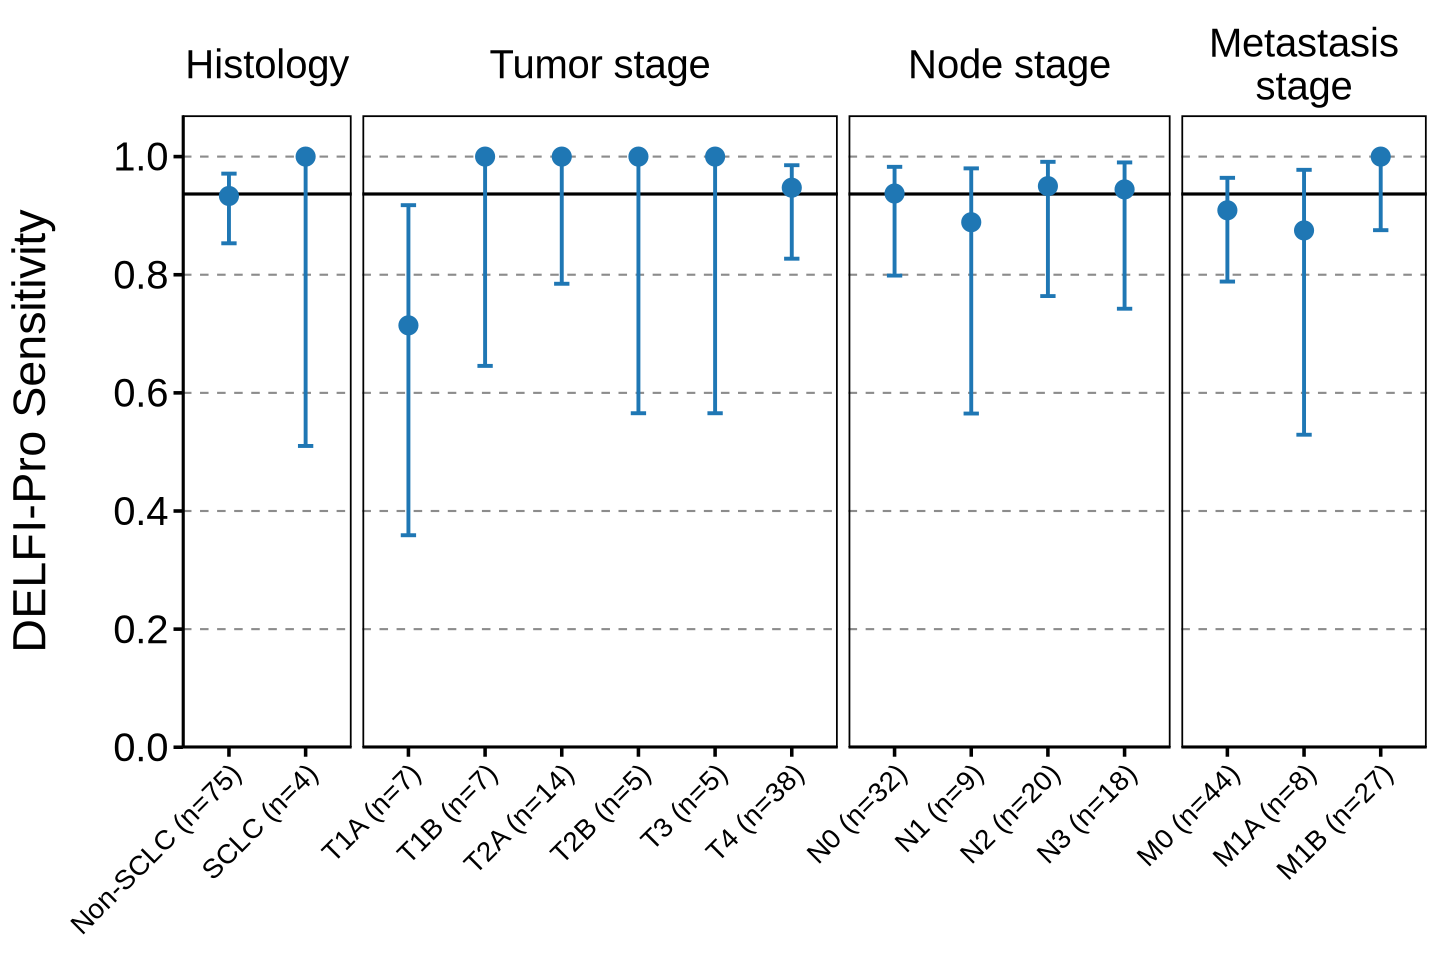

In [24]:
create_subgroup_sensitivity_figure <- function(
    model_name = "DELFI-Pro",
    specificity_cutoff = 0.80,
    se_level = 0.80,
    plot_width = 14,
    plot_height = 6,
    include_lucas_test = FALSE,
    lucas_test_data = NULL
) {

    # ── Model configuration ──────────────────────────────────────────────
    model_map <- list(
        "DELFI"       = list(idx = 1, score_col_test = "score.seq"),
        "Proteomics"  = list(idx = 2, score_col_test = "score.olink"),
        "DELFI-Pro"   = list(idx = 3, score_col_test = "score.seq.olink")
    )
    model_info <- model_map[[model_name]]
    if (is.null(model_info)) stop("model_name must be one of: DELFI, Proteomics, DELFI-Pro")

    # ── Helpers ─────────────────────────────────────────────────────────
    prefix_stage <- function(x, prefix) {
        x <- as.character(x)
        ifelse(grepl(paste0("^", prefix), x), x, paste0(prefix, x))
    }

    # ── LUCAS training data ──────────────────────────────────────────────
    overall <- dplyr::bind_rows(dat1, dat2, dat3) %>%
        dplyr::mutate(training_model = factor(.data$training_model, model_levels)) %>%
        dplyr::left_join(clindat, by = "lab_id") %>%
        dplyr::mutate(
            class = ifelse(.data$patient_type %in% nocancer_labels, "No cancer", "Cancer"),
            class = factor(.data$class, c("No cancer", "Cancer"))
        )

    overall.list <- split(overall, overall$training_model)

    # ── Lock threshold from training ROC ─────────────────────────────────
    roc_data <- overall.list[[model_info$idx]] %>% dplyr::select(score, class)
    tmp <- pROC::roc(class ~ score, data = roc_data, quiet = TRUE)

    cutoff_row <- tibble::tibble(
        sens = tmp$sens, spec = tmp$spec, thresholds = tmp$thresholds
    ) %>%
        dplyr::filter(.data$spec >= specificity_cutoff) %>%
        dplyr::arrange(.data$spec) %>%
        dplyr::slice(1)

    if (nrow(cutoff_row) == 0) {
        stop("No ROC threshold achieves the requested specificity_cutoff. Lower the cutoff.")
    }
    locked_threshold <- cutoff_row$thresholds[[1]]

    # ── Build TRAIN dataset with meta ────────────────────────────────────
    train_data <- overall.list[[model_info$idx]] %>%
        dplyr::left_join(
            meta %>% dplyr::select(lab_id, t_stage, n_stage, m_stage, histology),
            by = "lab_id"
        )

    # ── Optionally pool in LUCAS test set ────────────────────────────────
    pooled_data <- train_data

    if (isTRUE(include_lucas_test)) {
        if (is.null(lucas_test_data)) {
            stop("include_lucas_test=TRUE requires lucas_test_data.")
        }

        score_col_test <- model_info$score_col_test
        if (!(score_col_test %in% names(lucas_test_data))) {
            stop(paste0("lucas_test_data is missing required score column: ", score_col_test))
        }
        if (!all(c("lab_id", "class") %in% names(lucas_test_data))) {
            stop("lucas_test_data must contain columns: lab_id, class, and the model-specific score column.")
        }

        test_data <- lucas_test_data %>%
            dplyr::transmute(
                lab_id = .data$lab_id,
                class  = factor(.data$class, c("No cancer", "Cancer")),
                score  = .data[[score_col_test]]
            ) %>%
            dplyr::left_join(
                meta %>% dplyr::select(lab_id, t_stage, n_stage, m_stage, histology),
                by = "lab_id"
            )

        pooled_data <- dplyr::bind_rows(
            train_data %>% dplyr::mutate(dataset = "Training (LUCAS)"),
            test_data  %>% dplyr::mutate(dataset = "Test (LUCAS)")
        )
    } else {
        pooled_data <- pooled_data %>% dplyr::mutate(dataset = "Training (LUCAS)")
    }

    # ── Drop literal "NA" strings (and real NA) for TNM ──────────────────
    pooled_data <- pooled_data %>%
        dplyr::filter(
            !is.na(.data$t_stage), .data$t_stage != "NA",
            !is.na(.data$n_stage), .data$n_stage != "NA",
            !is.na(.data$m_stage), .data$m_stage != "NA"
        )

    # ── Overall sensitivity at locked threshold (on pooled cancer) ───────
    cancer <- pooled_data %>% dplyr::filter(.data$class == "Cancer")
    n_cancer <- nrow(cancer)
    if (n_cancer == 0) stop("No cancer samples found after pooling/filters.")

    tp_overall <- sum(cancer$score >= locked_threshold, na.rm = TRUE)
    sens_overall <- tp_overall / n_cancer

    # ── Helper: compute sensitivity with Wilson CI for a subgroup ────────
    compute_sens <- function(data, group_col, threshold, se_level) {
        data %>%
            dplyr::filter(.data$class == "Cancer", !is.na(.data[[group_col]])) %>%
            dplyr::group_by(subgroup = .data[[group_col]]) %>%
            dplyr::summarise(
                n  = dplyr::n(),
                tp = sum(.data$score >= threshold, na.rm = TRUE),
                sens = .data$tp / .data$n,
                .groups = "drop"
            ) %>%
            dplyr::mutate(
                lower = purrr::map2_dbl(tp, n, ~ prop.test(.x, .y, conf.level = se_level, correct = FALSE)$conf.int[1]),
                upper = purrr::map2_dbl(tp, n, ~ prop.test(.x, .y, conf.level = se_level, correct = FALSE)$conf.int[2]),
                label = paste0(.data$subgroup, " (n=", .data$n, ")")
            )
    }

    # ── Histology: SCLC vs Non-SCLC ──────────────────────────────────────
    histo_perf <- pooled_data %>%
        dplyr::filter(.data$class == "Cancer") %>%
        dplyr::mutate(
            histo_group = ifelse(
                !is.na(.data$histology) & .data$histology != "NA" & .data$histology == "SCLC",
                "SCLC",
                "Non-SCLC"
            )
        ) %>%
        dplyr::group_by(subgroup = .data$histo_group) %>%
        dplyr::summarise(
            n  = dplyr::n(),
            tp = sum(.data$score >= locked_threshold, na.rm = TRUE),
            sens = .data$tp / .data$n,
            .groups = "drop"
        ) %>%
        dplyr::mutate(
            lower = purrr::map2_dbl(tp, n, ~ prop.test(.x, .y, conf.level = se_level, correct = FALSE)$conf.int[1]),
            upper = purrr::map2_dbl(tp, n, ~ prop.test(.x, .y, conf.level = se_level, correct = FALSE)$conf.int[2]),
            label = paste0(.data$subgroup, " (n=", .data$n, ")"),
            facet = "Histology"
        )

    # ── Tumor stage (DROP aggregate "2" so only 2A/2B) ───────────────────
    t_perf <- pooled_data %>%
        dplyr::filter(.data$t_stage != "2") %>%
        compute_sens("t_stage", locked_threshold, se_level) %>%
        dplyr::mutate(
            subgroup = prefix_stage(.data$subgroup, "T"),
            label    = paste0(.data$subgroup, " (n=", .data$n, ")"),
            facet    = "Tumor stage"
        )

    # ── Node stage ───────────────────────────────────────────────────────
    n_perf <- compute_sens(pooled_data, "n_stage", locked_threshold, se_level) %>%
        dplyr::mutate(
            subgroup = prefix_stage(.data$subgroup, "N"),
            label    = paste0(.data$subgroup, " (n=", .data$n, ")"),
            facet    = "Node stage"
        )

    # ── Metastasis stage ─────────────────────────────────────────────────
    m_perf <- compute_sens(pooled_data, "m_stage", locked_threshold, se_level) %>%
        dplyr::mutate(
            subgroup = prefix_stage(.data$subgroup, "M"),
            label    = paste0(.data$subgroup, " (n=", .data$n, ")"),
            facet    = "Metastasis\nstage"
        )

    # ── Combine ──────────────────────────────────────────────────────────
    all_perf <- dplyr::bind_rows(histo_perf, t_perf, n_perf, m_perf) %>%
        dplyr::filter(!is.na(.data$sens), !is.na(.data$lower), !is.na(.data$upper), !is.na(.data$label)) %>%
        dplyr::mutate(
            facet = factor(.data$facet, levels = c("Histology", "Tumor stage", "Node stage", "Metastasis\nstage"))
        )

    # ── Order labels within each facet ───────────────────────────────────
    label_order <- all_perf %>%
        dplyr::arrange(.data$facet, .data$subgroup) %>%
        dplyr::pull(.data$label) %>%
        unique()

    all_perf <- all_perf %>%
        dplyr::mutate(label = factor(.data$label, levels = label_order))

    # ── Plot ─────────────────────────────────────────────────────────────
    plot_subgroup_sensitivity <- function(df, sens_overall, plot_width, plot_height) {

        options(repr.plot.width = plot_width, repr.plot.height = plot_height)

        ggplot2::ggplot(df, ggplot2::aes(x = label, y = sens)) +

            ggplot2::geom_hline(
                yintercept = sens_overall,
                color = "black",
                linewidth = 0.9
            ) +

            ggplot2::geom_hline(
                yintercept = seq(0, 1, 0.2),
                linetype = "dashed",
                color = "gray55",
                linewidth = 0.6
            ) +

            ggplot2::geom_errorbar(
                ggplot2::aes(ymin = lower, ymax = upper),
                width = 0.20,
                color = "#1f77b4",
                linewidth = 1.1
            ) +

            ggplot2::geom_point(
                color = "#1f77b4",
                size = 5
            ) +

            ggplot2::facet_grid(
                . ~ facet,
                scales = "free_x",
                space  = "free_x"
            ) +

            ggplot2::scale_y_continuous(
                limits = c(0, 1.05),
                breaks = seq(0, 1, 0.2),
                expand = ggplot2::expansion(add = c(0, 0.02))
            ) +

            ggplot2::labs(
                x = NULL,
                y = "DELFI-Pro Sensitivity\n"
            ) +

            ggplot2::theme_classic(base_size = 16) +
            ggplot2::theme(
                panel.border = ggplot2::element_rect(
                    color = "black",
                    fill  = NA,
                    linewidth = 1.0
                ),
                panel.spacing.x = grid::unit(0.45, "lines"),
                strip.background = ggplot2::element_blank(),
                strip.text = ggplot2::element_text(size = 24, color = "black"),
                axis.text.x = ggplot2::element_text(
                    angle = 45, hjust = 1, vjust = 1,
                    size = 17, color = "black"
                ),
                axis.text.y  = ggplot2::element_text(size = 24, color = "black"),
                axis.title.y = ggplot2::element_text(size = 28),
                axis.ticks   = ggplot2::element_line(color = "black", linewidth = 1),
                axis.ticks.length = grid::unit(0.2, "cm")
            )
    }

    p <- plot_subgroup_sensitivity(
        df           = all_perf,
        sens_overall = sens_overall,
        plot_width   = plot_width,
        plot_height  = plot_height
    )

    return(list(
        plot               = p,
        overall_sensitivity = sens_overall,
        subgroup_data      = all_perf,
        threshold          = locked_threshold,
        n_cancer           = n_cancer
    ))
}

# ── Usage ────────────────────────────────────────────────────────────────────

lucas_test <- combined_val %>% dplyr::filter(cohort == "LUCAS")

result <- create_subgroup_sensitivity_figure(
    model_name        = "DELFI-Pro",
    specificity_cutoff = 0.60,
    se_level          = 0.95,
    plot_width        = 12,
    plot_height       = 8,
    include_lucas_test = TRUE,
    lucas_test_data   = lucas_test
)

result$plot
result$overall_sensitivity
result$subgroup_data %>% dplyr::select(facet, subgroup, n, sens, lower, upper)

In [25]:
ggsave("../../outputs/Fig6/Fig-DELFI-PRO-TMNH.png",
       plot = result$plot, width = 18, height = 12, units = "in", dpi = 600)

## Stage and Histology Sensitivities across Spec.

In [26]:
## ── Stage-specific + Overall sensitivity at multiple specificities, LUCAS Training Set ──
## Paired two-sided exact McNemar: DELFI-Pro vs DELFI and vs Proteomics.
## Reports nominal AND BH (FDR)-adjusted p-values (families defined below).
suppressMessages(library(tidyverse))

stage_col     <- "stage"                            
target_specs  <- c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95)    # spc to evaluate
stage_keep    <- c("I", "II", "III", "IV")          
strata_all    <- c("Overall", stage_keep)
min_evaluable <- 5                                  

delfi <- model_levels[1]; prot <- model_levels[2]; dpro <- model_levels[3]

## ---- helper: build one specificity slice ----------------------------------
build_slice <- function(spec_target) {

  thr_tbl <- overall %>%
    filter(class == "No cancer") %>%
    group_by(training_model) %>%
    summarise(thr = quantile(score, probs = spec_target), .groups = "drop")

  called <- overall %>%
    left_join(thr_tbl, by = "training_model") %>%
    mutate(pred_pos = score >= thr)

  ## augment: add an "Overall" copy of ALL cancer rows (incl. unstaged)
  called_aug <- bind_rows(
    called,
    called %>% filter(class == "Cancer") %>% mutate(!!stage_col := "Overall")
  )

  ## sensitivity + exact 95% CI, per stratum per model
  sens_tbl <- called_aug %>%
    filter(class == "Cancer", .data[[stage_col]] %in% strata_all) %>%
    group_by(stratum = .data[[stage_col]], training_model) %>%
    summarise(n = n(), tp = sum(pred_pos), .groups = "drop") %>%
    rowwise() %>%
    mutate(sens = tp / n,
           lwr  = prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[1],
           upr  = prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[2],
           cell = sprintf("%.2f (%.2f-%.2f) [%d/%d]", sens, lwr, upr, tp, n)) %>%
    ungroup()

  ## paired exact McNemar (two-sided): DELFI-Pro vs one comparator, within a stratum
  mcnemar_pair <- function(df, m_ref, m_alt) {
    w <- df %>%
      filter(class == "Cancer", training_model %in% c(m_ref, m_alt)) %>%
      select(lab_id, training_model, pred_pos) %>%
      pivot_wider(names_from = training_model, values_from = pred_pos)
    n_eval <- sum(stats::complete.cases(w[, c(m_ref, m_alt)]))
    b  <- sum(w[[m_ref]] & !w[[m_alt]], na.rm = TRUE)   # ref+ alt-
    cc <- sum(!w[[m_ref]] & w[[m_alt]], na.rm = TRUE)   # ref- alt+
    p  <- if (n_eval < min_evaluable || (b + cc) == 0) NA_real_
          else binom.test(b, b + cc, 0.5)$p.value       # exact, two-sided
    tibble(discordant = b + cc, n_eval = n_eval, p = p)
  }

  mc_tbl <- called_aug %>%
    filter(.data[[stage_col]] %in% strata_all) %>%
    group_split(.data[[stage_col]]) %>%
    map_dfr(function(ds) {
      st <- unique(ds[[stage_col]])
      bind_rows(
        mcnemar_pair(ds, dpro, delfi) %>% mutate(comparison = "DELFI-Pro vs DELFI"),
        mcnemar_pair(ds, dpro, prot)  %>% mutate(comparison = "DELFI-Pro vs Proteomics")
      ) %>% mutate(stratum = st, .before = 1)
    })

  list(sens = sens_tbl %>% mutate(specificity = spec_target),
       mc   = mc_tbl   %>% mutate(specificity = spec_target))
}

## ---- run across all specificities -----------------------------------------
slices   <- map(target_specs, build_slice)
sens_all <- map_dfr(slices, "sens")
mc_all   <- map_dfr(slices, "mc")

## ---- BH (FDR) within each family (Overall separate from stages) -----------
## m counts only TESTABLE (non-NA) comparisons in the family.
mc_all <- mc_all %>%
  mutate(stratum_type = ifelse(stratum == "Overall", "Overall", "Stage")) %>%
  group_by(specificity, stratum_type) %>%
  mutate(m_family = sum(!is.na(p)),
         p_adj    = p.adjust(p, method = "BH", n = sum(!is.na(p)))) %>%
  ungroup()

## ---- assemble readable wide table -----------------------------------------
sens_wide <- sens_all %>%
  mutate(model = recode(training_model,
                        !!delfi := "DELFI", !!prot := "Proteomics", !!dpro := "DELFI-Pro")) %>%
  select(specificity, stratum, model, cell) %>%
  pivot_wider(names_from = model, values_from = cell)

p_wide <- mc_all %>%
  mutate(comparison = recode(comparison,
                             "DELFI-Pro vs DELFI"      = "vsDELFI",
                             "DELFI-Pro vs Proteomics" = "vsProt"),
         p_nom = ifelse(is.na(p),     "—", formatC(p,     format = "f", digits = 3)),
         p_fdr = ifelse(is.na(p_adj), "—", formatC(p_adj, format = "f", digits = 3))) %>%
  select(specificity, stratum, comparison, p_nom, p_fdr) %>%
  pivot_wider(names_from = comparison, values_from = c(p_nom, p_fdr),
              names_glue = "{comparison}_{.value}")

final_tbl <- sens_wide %>%
  left_join(p_wide, by = c("specificity", "stratum")) %>%
  mutate(stratum = factor(stratum, levels = strata_all)) %>%
  arrange(specificity, stratum) %>%
  select(specificity, stratum, DELFI, Proteomics, `DELFI-Pro`,
         vsDELFI_p_nom, vsDELFI_p_fdr, vsProt_p_nom, vsProt_p_fdr)

print(as.data.frame(final_tbl), row.names = FALSE)

write_csv(final_tbl, "../../outputs/Extended/Stage_sensitivity_by_specificity.csv")

Warning message:
“There were 12 warnings in `mutate()`.
The first warning was:
ℹ In argument: `lwr = prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[1]`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 11 remaining warnings.”
Warning message:
“There were 12 warnings in `mutate()`.
The first warning was:
ℹ In argument: `lwr = prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[1]`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 11 remaining warnings.”
Warning message:
“There were 12 warnings in `mutate()`.
The first warning was:
ℹ In argument: `lwr = prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[1]`.
ℹ In row 1.
Caused by warning in `prop.test()`:
! Chi-squared approximation may be incorrect
ℹ Run `dplyr::last_dplyr_warnings()` to see the 11 remaining warnings.”
W

 specificity stratum                    DELFI               Proteomics
        0.50 Overall 0.97 (0.89-0.99) [58/60] 0.90 (0.80-0.95) [54/60]
        0.50       I   0.89 (0.57-0.98) [8/9]   0.67 (0.35-0.88) [6/9]
        0.50      II   1.00 (0.51-1.00) [4/4]   0.75 (0.30-0.95) [3/4]
        0.50     III 1.00 (0.82-1.00) [18/18] 0.94 (0.74-0.99) [17/18]
        0.50      IV 0.97 (0.83-0.99) [28/29] 0.97 (0.83-0.99) [28/29]
        0.60 Overall 0.88 (0.78-0.94) [53/60] 0.82 (0.70-0.89) [49/60]
        0.60       I   0.78 (0.45-0.94) [7/9]   0.22 (0.06-0.55) [2/9]
        0.60      II   0.75 (0.30-0.95) [3/4]   0.75 (0.30-0.95) [3/4]
        0.60     III 0.89 (0.67-0.97) [16/18] 0.94 (0.74-0.99) [17/18]
        0.60      IV 0.93 (0.78-0.98) [27/29] 0.93 (0.78-0.98) [27/29]
        0.70 Overall 0.78 (0.66-0.87) [47/60] 0.73 (0.61-0.83) [44/60]
        0.70       I   0.67 (0.35-0.88) [6/9]   0.22 (0.06-0.55) [2/9]
        0.70      II   0.50 (0.15-0.85) [2/4]   0.75 (0.30-0.95) [3/4]
      

In [27]:
## ── Histology-specific + Overall sensitivity at multiple specificities, LUCAS Training Set ──

suppressMessages(library(tidyverse))

## ---- assumptions (verify these once) --------------------------------------
histo_col     <- "histology"
target_specs  <- c(0.50, 0.60, 0.70, 0.80, 0.90, 0.95)
histo_keep    <- c("Adenocarcinoma", "Squamous", "SCLC")
strata_all    <- c("Overall", histo_keep)
min_evaluable <- 5

delfi <- model_levels[1]; prot <- model_levels[2]; dpro <- model_levels[3]

## ---- helper: build one specificity slice ----------------------------------
build_slice <- function(spec_target) {

  thr_tbl <- overall %>%
    filter(class == "No cancer") %>%
    group_by(training_model) %>%
    summarise(thr = quantile(score, probs = spec_target), .groups = "drop")

  called <- overall %>%
    left_join(thr_tbl, by = "training_model") %>%
    mutate(pred_pos = score >= thr)

  called_aug <- bind_rows(
    called,
    called %>% filter(class == "Cancer") %>% mutate(!!histo_col := "Overall")
  )

  sens_tbl <- called_aug %>%
    filter(class == "Cancer", .data[[histo_col]] %in% strata_all) %>%
    group_by(stratum = .data[[histo_col]], training_model) %>%
    summarise(n = n(), tp = sum(pred_pos), .groups = "drop") %>%
    rowwise() %>%
    mutate(sens = tp / n,
           lwr  = suppressWarnings(prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[1]),
           upr  = suppressWarnings(prop.test(tp, n, conf.level = 0.95, correct = FALSE)$conf.int[2]),
           cell = sprintf("%.2f (%.2f-%.2f) [%d/%d]", sens, lwr, upr, tp, n)) %>%
    ungroup()

  mcnemar_pair <- function(df, m_ref, m_alt) {
    w <- df %>%
      filter(class == "Cancer", training_model %in% c(m_ref, m_alt)) %>%
      select(lab_id, training_model, pred_pos) %>%
      pivot_wider(names_from = training_model, values_from = pred_pos)
    n_eval <- sum(stats::complete.cases(w[, c(m_ref, m_alt)]))
    b  <- sum(w[[m_ref]] & !w[[m_alt]], na.rm = TRUE)
    cc <- sum(!w[[m_ref]] & w[[m_alt]], na.rm = TRUE)
    p  <- if (n_eval < min_evaluable || (b + cc) == 0) NA_real_
          else binom.test(b, b + cc, 0.5)$p.value
    tibble(discordant = b + cc, n_eval = n_eval, p = p)
  }

  mc_tbl <- called_aug %>%
    filter(.data[[histo_col]] %in% strata_all) %>%
    group_split(.data[[histo_col]]) %>%
    map_dfr(function(ds) {
      st <- unique(ds[[histo_col]])
      bind_rows(
        mcnemar_pair(ds, dpro, delfi) %>% mutate(comparison = "DELFI-Pro vs DELFI"),
        mcnemar_pair(ds, dpro, prot)  %>% mutate(comparison = "DELFI-Pro vs Proteomics")
      ) %>% mutate(stratum = st, .before = 1)
    })

  list(sens = sens_tbl %>% mutate(specificity = spec_target),
       mc   = mc_tbl   %>% mutate(specificity = spec_target))
}

## ---- run across all specificities -----------------------------------------
slices   <- map(target_specs, build_slice)
sens_all <- map_dfr(slices, "sens")
mc_all   <- map_dfr(slices, "mc")

## ---- BH (FDR) within each family (Overall separate from histologies) ------
mc_all <- mc_all %>%
  mutate(stratum_type = ifelse(stratum == "Overall", "Overall", "Histology")) %>%
  group_by(specificity, stratum_type) %>%
  mutate(m_family = sum(!is.na(p)),
         p_adj    = p.adjust(p, method = "BH", n = sum(!is.na(p)))) %>%
  ungroup()

## ---- assemble readable wide table -----------------------------------------
sens_wide <- sens_all %>%
  mutate(model = recode(training_model,
                        !!delfi := "DELFI", !!prot := "Proteomics", !!dpro := "DELFI-Pro")) %>%
  select(specificity, stratum, model, cell) %>%
  pivot_wider(names_from = model, values_from = cell)

p_wide <- mc_all %>%
  mutate(comparison = recode(comparison,
                             "DELFI-Pro vs DELFI"      = "vsDELFI",
                             "DELFI-Pro vs Proteomics" = "vsProt"),
         p_nom = ifelse(is.na(p),     "—", formatC(p,     format = "f", digits = 3)),
         p_fdr = ifelse(is.na(p_adj), "—", formatC(p_adj, format = "f", digits = 3))) %>%
  select(specificity, stratum, comparison, p_nom, p_fdr) %>%
  pivot_wider(names_from = comparison, values_from = c(p_nom, p_fdr),
              names_glue = "{comparison}_{.value}")

final_tbl_histo <- sens_wide %>%
  left_join(p_wide, by = c("specificity", "stratum")) %>%
  mutate(stratum = factor(stratum, levels = strata_all)) %>%
  arrange(specificity, stratum) %>%
  select(specificity, stratum, DELFI, Proteomics, `DELFI-Pro`,
         vsDELFI_p_nom, vsDELFI_p_fdr, vsProt_p_nom, vsProt_p_fdr)

print(as.data.frame(final_tbl_histo), row.names = FALSE)

write_csv(final_tbl_histo, "../../outputs/Extended/Histology_sensitivity_by_specificity.csv")

 specificity        stratum                    DELFI               Proteomics
        0.50        Overall 0.97 (0.89-0.99) [58/60] 0.90 (0.80-0.95) [54/60]
        0.50 Adenocarcinoma 0.97 (0.85-0.99) [33/34] 0.88 (0.73-0.95) [30/34]
        0.50       Squamous 1.00 (0.82-1.00) [18/18] 0.89 (0.67-0.97) [16/18]
        0.50           SCLC   0.80 (0.38-0.96) [4/5]   1.00 (0.57-1.00) [5/5]
        0.60        Overall 0.88 (0.78-0.94) [53/60] 0.82 (0.70-0.89) [49/60]
        0.60 Adenocarcinoma 0.82 (0.66-0.92) [28/34] 0.82 (0.66-0.92) [28/34]
        0.60       Squamous 1.00 (0.82-1.00) [18/18] 0.78 (0.55-0.91) [14/18]
        0.60           SCLC   0.80 (0.38-0.96) [4/5]   1.00 (0.57-1.00) [5/5]
        0.70        Overall 0.78 (0.66-0.87) [47/60] 0.73 (0.61-0.83) [44/60]
        0.70 Adenocarcinoma 0.71 (0.54-0.83) [24/34] 0.74 (0.57-0.85) [25/34]
        0.70       Squamous 0.89 (0.67-0.97) [16/18] 0.67 (0.44-0.84) [12/18]
        0.70           SCLC   0.80 (0.38-0.96) [4/5]   1.00 (0.5

In [ ]:
# Done #